# Perfil económico de los municipios de Morelos por tipo de actividad

> ## Pregunta de investigación
>
> **¿Qué municipios del estado de Morelos comparten un perfil económico similar según la concentración
> de sus unidades económicas dedicadas a la manufactura, el comercio y los servicios?**

**Tema:** 2 — Perfil económico de municipios por tipo de actividad
**Modelo:** KMeans (aprendizaje **no supervisado**)
**Unidad de análisis:** el municipio, no el establecimiento individual.

---

## 0.1 Justificación: por qué esta pregunta

**1. Responde a lo que el agrupamiento sabe hacer.** El objetivo es identificar municipios con perfiles
económicos afines. KMeans permite descubrir "vecindarios económicos": grupos de municipios con una
estructura de unidades económicas parecida independientemente de su cercanía geográfica. La geografía
no entra al modelo, si al final aparece un patrón territorial, será un hallazgo, no un supuesto.

**2. Descubre patrones que la estadística descriptiva no alcanza.** Comparar 36 municipios a lo largo de
9 variables al mismo tiempo no es algo que se pueda hacer leyendo tablas. El aprendizaje no supervisado
permite una categorización basada en datos, capaz de aislar —por ejemplo— demarcaciones de vocación
netamente comercial frente a otras con un perfil industrial consolidado.

**3. Tiene utilidad práctica.** Conocer la composición de unidades económicas de una región convierte
datos crudos en información útil: focalización de servicios B2B, distribución de soluciones
especializadas o diseño de política pública de desarrollo económico regional.

**4. Y tiene un alcance acotado, que declaramos desde el inicio.** La segmentación se basa
exclusivamente en la frecuencia y el volumen de unidades económicas registradas formalmente. No
contempla facturación, márgenes de ingreso ni el sector informal, porque el DENUE simplemente no los
captura. Las conclusiones se limitan a la composición estructural del mercado formal.

## 0. Procedencia de los datos

| Campo | Valor |
|---|---|
| **Fuente** | DENUE — Directorio Estadístico Nacional de Unidades Económicas |
| **Institución** | INEGI (Instituto Nacional de Estadística y Geografía) |
| **URL de descarga** | https://www.inegi.org.mx/app/descarga/?ti=6 |
| **Corte / versión** | **DENUE 2026/06** (reporte de junio de 2026) |
| **Fecha de descarga** | Agosto de 2026 (el archivo se incorporó al repositorio el 2026-08-23) |
| **Cobertura geográfica** | Estado de Morelos (`cve_ent = 17`), 36 municipios |
| **Unidad de registro** | Un establecimiento (unidad económica) por fila |
| **Registros** | 113,066 |
| **Variables originales** | 42 |
| **Codificación del archivo** | `latin-1` (el DENUE no se distribuye en UTF-8) |

**¿Por qué consideramos confiable la fuente?**
El DENUE es el directorio oficial de establecimientos del INEGI, construido a partir de los Censos
Económicos y actualizado con recorridos de campo. Es de acceso público, gratuito y descargable en CSV,
lo que hace el análisis reproducible por cualquier persona.

**Limitación desde el origen:** el DENUE registra la existencia de un establecimiento y su actividad,
pero no su producción, ingresos ni valor agregado. Esto acota lo que podemos afirmar y se retoma en
la sección 16.

---
## 1. Carga de librerías y del dataset

In [1]:
# Librerías de manejo de datos
import pandas as pd
import numpy as np
# Gráficas
import matplotlib.pyplot as plt
# Manejo de rutas
from pathlib import Path

# Modelo no supervisado y herramientas de apoyo
from sklearn.preprocessing import StandardScaler # escalado
from sklearn.cluster import KMeans # modelo
from sklearn.metrics import silhouette_score # métrica
from sklearn.decomposition import PCA # graficar en 2D

# Semilla global para replicabilidad
np.random.seed(42)

# Consistencia del formato
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Versiones utilizadas:
import sys
print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
import matplotlib, sklearn
print('matplotlib:', matplotlib.__version__)
print('scikit-learn:', sklearn.__version__)

Python: 3.12.10
pandas: 3.0.5
numpy: 2.5.2
matplotlib: 3.11.1
scikit-learn: 1.9.0


In [3]:
# Derivamos la ruta base para evitar que fallen las rutas relativas
BASE = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()

RUTA_RAW = BASE / 'data' / 'raw' / 'dataset_original.csv'
RUTA_PROCESSED = BASE / 'data' / 'processed'
RUTA_OUTPUTS = BASE / 'outputs'
RUTA_IMAGENES = BASE / 'imagenes'
# Validar existencia del dataset
assert RUTA_RAW.exists(), f'No se encontró el dataset en {RUTA_RAW}'

print('Carpeta base del proyecto:', BASE.resolve())
print('Dataset original:', RUTA_RAW.name, '(', round(RUTA_RAW.stat().st_size / 1024 / 1024, 1), 'MB )')

Carpeta base del proyecto: C:\Users\cesar\Documents\perfil-economico-municipios-mx
Dataset original: dataset_original.csv ( 57.8 MB )


In [4]:
# encoding='latin-1' porque el DENUE no viene en UTF-8
# low_memory=False evita el aviso de tipos mixtos en un archivo de 113 mil filas.
df = pd.read_csv(RUTA_RAW, encoding='latin-1', low_memory=False)
print('Dataset cargado.')

Dataset cargado.


In [5]:
df.head()

,id,clee,nom_estab,raz_social,codigo_act,nombre_act,per_ocu,tipo_vial,nom_vial,tipo_v_e_1,...,localidad,ageb,manzana,telefono,correoelec,www,tipoUniEco,latitud,longitud,fecha_alta
0,12299614,17004112519000111000000000U2,NaN,NaN,112519,Otra acuicultura,0 a 5 personas,CALLEJON,NINGUNO,CALLE,...,Chinameca ...,0448,23,NaN,NaN,NaN,Fijo,18.619709,-99.003876,2026-04
1,12299633,17004112515000191000000000U2,NaN,NaN,112519,Otra acuicultura,0 a 5 personas,OTRO(ESPECIFIQUE),NINGUNO,OTRO(ESPECIFIQUE),...,Campo el Brasil ...,0170,800,7351928407,NaN,NaN,Fijo,18.629171,-98.997859,2026-04
2,12296784,17024112515000061000000000U5,NaN,NaN,112515,Piscicultura en agua dulce,0 a 5 personas,OTRO(ESPECIFIQUE),OTOÑO,OTRO(ESPECIFIQUE),...,San Pablo Hidalgo ...,0170,800,NaN,NaN,NaN,Fijo,18.587391,-99.041878,2026-04
3,12319974,17034114119000161000000000U1,NaN,NaN,114119,"Pesca y captura de peces, crustáceos, moluscos...",0 a 5 personas,PRIVADA,NINGUNO,PRIVADA,...,Coatetelco Centro ...,0061,10,7772625967,NaN,NaN,Fijo,18.727702,-99.336153,2026-04
4,6171821,17004112512000452010000000U5,NaN,NaN,112519,Otra acuicultura,0 a 5 personas,OTRO(ESPECIFIQUE),NINGUNO,CARRETERA,...,Unidad Piscícola Tenextepango ...,0151,800,NaN,NaN,NaN,Fijo,18.704083,-98.984093,2026-04


---
## 2. Revisión inicial del dataset

Antes de tocar nada, queremos saber con qué estamos trabajando: cuántas filas y columnas hay,
qué tipos de datos tiene y cómo se ven las columnas numéricas.

In [6]:
# Dimensiones del dataset (filas, columnas)
print('Shape del dataset:', df.shape)

Shape del dataset: (113066, 42)


In [7]:
# Nombres de todas las columnas
print('Columnas del dataset:')
print(list(df.columns))

Columnas del dataset:
['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']


In [8]:
# Tipos de datos por columna
df.dtypes

id              int64
clee              str
nom_estab         str
raz_social        str
codigo_act      int64
nombre_act        str
per_ocu           str
tipo_vial         str
nom_vial          str
tipo_v_e_1        str
nom_v_e_1         str
tipo_v_e_2        str
nom_v_e_2         str
tipo_v_e_3        str
nom_v_e_3         str
numero_ext    float64
letra_ext         str
edificio          str
edificio_e    float64
numero_int    float64
letra_int         str
tipo_asent        str
nomb_asent        str
tipoCenCom        str
nom_CenCom        str
num_local         str
cod_postal    float64
cve_ent         int64
entidad           str
cve_mun         int64
municipio         str
cve_loc         int64
localidad         str
ageb              str
manzana         int64
telefono          str
correoelec        str
www               str
tipoUniEco        str
latitud       float64
longitud      float64
fecha_alta        str
dtype: object

In [9]:
# Información general: tipos, no nulos y memoria usada
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113066 entries, 0 to 113065
Data columns (total 42 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          113066 non-null  int64  
 1   clee        113066 non-null  str    
 2   nom_estab   113006 non-null  str    
 3   raz_social  21800 non-null   str    
 4   codigo_act  113066 non-null  int64  
 5   nombre_act  113066 non-null  str    
 6   per_ocu     113066 non-null  str    
 7   tipo_vial   113065 non-null  str    
 8   nom_vial    113065 non-null  str    
 9   tipo_v_e_1  113044 non-null  str    
 10  nom_v_e_1   112982 non-null  str    
 11  tipo_v_e_2  113044 non-null  str    
 12  nom_v_e_2   112979 non-null  str    
 13  tipo_v_e_3  113044 non-null  str    
 14  nom_v_e_3   112950 non-null  str    
 15  numero_ext  52965 non-null   float64
 16  letra_ext   66954 non-null   str    
 17  edificio    2242 non-null    str    
 18  edificio_e  12279 non-null   float64
 19  numero_int  5

In [10]:
# Estadísticas descriptivas de las columnas numéricas.
df.describe()

,id,codigo_act,numero_ext,edificio_e,numero_int,cod_postal,cve_ent,cve_mun,cve_loc,manzana,latitud,longitud
count,1.130660e+05,113066.000000,52965.000000,12279.000000,5404.000000,113056.000000,113066.0,113066.000000,113066.000000,113066.000000,113066.000000,113066.000000
mean,7.208682e+06,560614.151381,159.524157,7.586774,119.291081,62606.170004,17.0,13.905321,4.511029,24.298100,18.830782,-99.100994
std,3.486446e+06,163043.932182,809.547822,7.942861,1315.305374,789.523333,0.0,9.403377,80.613612,69.345048,0.125026,0.172909
min,3.669810e+05,112514.000000,0.000000,1.000000,0.000000,0.000000,17.0,1.000000,1.000000,1.000000,18.480776,-111.786337
25%,2.844428e+06,461121.000000,9.000000,1.000000,2.000000,62520.000000,17.0,7.000000,1.000000,7.000000,18.772821,-99.229833
50%,8.030250e+06,466312.000000,30.000000,4.000000,10.000000,62718.000000,17.0,11.000000,1.000000,15.000000,18.866919,-99.178899
75%,1.036258e+07,722513.000000,110.000000,17.000000,70.000000,62778.000000,17.0,20.000000,1.000000,26.000000,18.920538,-98.953313
max,1.233800e+07,931810.000000,87500.000000,99.000000,77756.000000,88888.000000,17.0,36.000000,9003.000000,800.000000,28.688091,-90.533817


---
## 3. Revisión de duplicados

Un establecimiento repetido inflaría artificialmente el conteo de un municipio y por lo tanto
su perfil económico. Lo revisamos antes de cualquier otra cosa.

In [11]:
# Contar filas duplicadas
duplicados = df.duplicated().sum()
print('Filas duplicadas:', duplicados)

Filas duplicadas: 0


In [12]:
# Solo eliminamos si realmente hay duplicados, if para dejar documentado si se eliminó algo
if duplicados > 0:
    df = df.drop_duplicates()
    print('Duplicados eliminados. Nuevo shape:', df.shape)
else:
    print('No se encontraron duplicados. No se requiere acción.')

No se encontraron duplicados. No se requiere acción.


---
## 4. Revisión de valores nulos

In [13]:
# Total de nulos por columna
nulos = df.isnull().sum()
print('Nulos por columna:')
print(nulos)

Nulos por columna:
id                 0
clee               0
nom_estab         60
raz_social     91266
codigo_act         0
nombre_act         0
per_ocu            0
tipo_vial          1
nom_vial           1
tipo_v_e_1        22
nom_v_e_1         84
tipo_v_e_2        22
nom_v_e_2         87
tipo_v_e_3        22
nom_v_e_3        116
numero_ext     60101
letra_ext      46112
edificio      110824
edificio_e    100787
numero_int    107662
letra_int     107576
tipo_asent         9
nomb_asent         0
tipoCenCom    100354
nom_CenCom    100339
num_local     100348
cod_postal        10
cve_ent            0
entidad            0
cve_mun            0
municipio          0
cve_loc            0
localidad          0
ageb               0
manzana            0
telefono       78584
correoelec    100886
www           107793
tipoUniEco         0
latitud            0
longitud           0
fecha_alta         0
dtype: int64


In [14]:
# Porcentaje de nulos, mostrando solo las columnas que sí tienen nulos.
# Nos interesa el porcentaje y no el conteo para dimensionar el problema.
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).round(2)
nulos_filtrados = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)
print('Porcentaje de nulos (solo columnas con nulos):')
print(nulos_filtrados)

Porcentaje de nulos (solo columnas con nulos):
edificio      98.02
www           95.34
numero_int    95.22
letra_int     95.14
correoelec    89.23
edificio_e    89.14
tipoCenCom    88.76
num_local     88.75
nom_CenCom    88.74
raz_social    80.72
telefono      69.50
numero_ext    53.16
letra_ext     40.78
nom_v_e_3      0.10
nom_v_e_2      0.08
nom_v_e_1      0.07
nom_estab      0.05
tipo_v_e_1     0.02
tipo_v_e_2     0.02
tipo_v_e_3     0.02
tipo_asent     0.01
cod_postal     0.01
dtype: float64


**Interpretación:** Las columnas con porcentajes altos de nulos es debido a que son opcionales

Lo importante es que las columnas que sí vamos a usar (`municipio`, `nombre_act`, `codigo_act`,
`per_ocu`, `tipoUniEco`, `latitud`, `longitud`) no tienen ningún nulo. Por eso la decisión de limpieza
no es imputar ni rellenar, es descartar las columnas que no aportan al análisis

---
## 5. Revisión de valores únicos en columnas clave

Aquí verificamos que los datos digan lo que creemos que dicen: que sea solo Morelos, que estén los
36 municipios y qué forma tienen las variables categóricas que vamos a usar.

In [15]:
# Verificar que el archivo descargado contiene únicamente Morelos
print('Entidades únicas:', df['entidad'].nunique())
print(df['entidad'].unique())
print('Clave de entidad:', df['cve_ent'].unique())

Entidades únicas: 1
<StringArray>
['Morelos']
Length: 1, dtype: str
Clave de entidad: [17]


In [16]:
# Municipios: deben ser los 36 de Morelos
print('Municipios únicos:', df['municipio'].nunique())
print(sorted(df['municipio'].unique()))

Municipios únicos: 36
['Amacuzac', 'Atlatlahucan', 'Axochiapan', 'Ayala', 'Coatetelco', 'Coatlán del Río', 'Cuautla', 'Cuernavaca', 'Emiliano Zapata', 'Hueyapan', 'Huitzilac', 'Jantetelco', 'Jiutepec', 'Jojutla', 'Jonacatepec de Leandro Valle', 'Mazatepec', 'Miacatlán', 'Ocuituco', 'Puente de Ixtla', 'Temixco', 'Temoac', 'Tepalcingo', 'Tepoztlán', 'Tetecala', 'Tetela del Volcán', 'Tlalnepantla', 'Tlaltizapán de Zapata', 'Tlaquiltenango', 'Tlayacapan', 'Totolapan', 'Xochitepec', 'Xoxocotla', 'Yautepec', 'Yecapixtla', 'Zacatepec', 'Zacualpan de Amilpas']


In [17]:
# Actividades económicas más frecuentes.
print('Top 10 actividades económicas:')
print(df['nombre_act'].value_counts().head(10))

Top 10 actividades económicas:
nombre_act
Comercio al por menor en tiendas de abarrotes, ultramarinos y misceláneas    12962
Salones y clínicas de belleza y peluquerías                                   5390
Restaurantes con servicio de preparación de antojitos                         4110
Comercio al por menor de ropa, excepto de bebé y lencería                     3234
Restaurantes con servicio de preparación de tacos y tortas                    2938
Comercio al por menor de artículos de papelería                               2839
Comercio al por menor de frutas y verduras frescas                            2674
Elaboración de tortillas de maíz y molienda de nixtamal                       2589
Asociaciones y organizaciones religiosas                                      2215
Comercio al por menor de carne de aves                                        1968
Name: count, dtype: int64


In [18]:
# per_ocu no es un número de empleados, es un rango categórico.
print('Distribución de personal ocupado (per_ocu):')
print(df['per_ocu'].value_counts())

Distribución de personal ocupado (per_ocu):
per_ocu
0 a 5 personas        101715
6 a 10 personas         6310
11 a 30 personas        3538
31 a 50 personas         634
51 a 100 personas        460
101 a 250 personas       281
251 y más personas       128
Name: count, dtype: int64


In [19]:
# tipoUniEco distingue establecimientos fijos de semifijos (puestos, tianguis).
print('Tipos de unidad económica:')
print(df['tipoUniEco'].value_counts())

Tipos de unidad económica:
tipoUniEco
Fijo        110174
Semifijo      2892
Name: count, dtype: int64


In [20]:
# Corte temporal: fecha_alta indica cuándo se dio de alta el registro.
print('fecha_alta más antigua :', df['fecha_alta'].min())
print('fecha_alta más reciente:', df['fecha_alta'].max())
print()
print('Mayores altas por año:')
print(df['fecha_alta'].astype(str).str[:4].value_counts().head(5))

fecha_alta más antigua : 2010-07
fecha_alta más reciente: 2026-04

Mayores altas por año:


fecha_alta
2024    38009
2010    28369
2019    23205
2014    13787
2025     4581
Name: count, dtype: int64


In [21]:
# Validar que el corte de datos sea como se documentó, revisando que no hayan fechas mayores a Junio del 2026
CORTE_DENUE = '2026-06'

alta_maxima = df['fecha_alta'].max()
print('Corte declarado del DENUE :', CORTE_DENUE)
print('Alta más reciente del archivo:', alta_maxima)
print()

if alta_maxima <= CORTE_DENUE:
    print('OK: el archivo es consistente con el corte declarado')
    print('No hay registros posteriores a', CORTE_DENUE)
else:
    print('ATENCIÓN: hay altas posteriores al corte declarado. Revisar la versión.')

Corte declarado del DENUE : 2026-06
Alta más reciente del archivo: 2026-04

OK: el archivo es consistente con el corte declarado
No hay registros posteriores a 2026-06


**Hallazgos de la revisión inicial:**

1. El archivo contiene una sola entidad, Morelos, y los 36 municipios completos.
2. `per_ocu` es un rango categórico, no un conteo. El 90% de los registros cae en `0 a 5 personas`.
3. `tipoUniEco` tiene solo dos valores: `Fijo` (110,174) y `Semifijo` (2,892).
4. El comercio al por menor domina el directorio: las actividades más frecuentes son abarrotes,
   ropa y alimentos preparados. Esto anticipa que la diferencia entre municipios no va a estar en
   quién tiene comercio, sino en el margen: quién tiene además manufactura, turismo o servicios

---
## 6. Limpieza básica

1. **Seleccionar** solo las columnas relevantes (de 42 a 11): descartamos domicilio, contacto y
   claves geográficas finas que no aportan al perfil económico municipal.
2. **Crear `sector_nombre`**: el sector SCIAN a partir de los 2 primeros dígitos de `codigo_act`.
   Sin esto solo tendríamos ~1,000 actividades sueltas, imposibles de comparar entre municipios.
3. **Crear `cve_geo`**: la clave INEGI estándar de 5 dígitos (entidad + municipio), para trazabilidad.
4. **Verificar** que no queden nulos ni identificadores repetidos en las columnas que sí usamos.

In [22]:
# Seleccionamos las columnas relevantes para el perfil económico municipal.
columnas_relevantes = [
    'id',           # Identificador único de la unidad económica
    'codigo_act',   # Código de actividad económica (SCIAN)
    'nombre_act',   # Nombre de la actividad económica
    'per_ocu',      # Rango de personal ocupado
    'cve_ent',      # Clave de la entidad (17 = Morelos)
    'cve_mun',      # Clave del municipio
    'municipio',    # Nombre del municipio
    'entidad',      # Nombre de la entidad
    'tipoUniEco',   # Tipo de unidad económica (Fijo / Semifijo)
    'latitud',      # Latitud del establecimiento
    'longitud'      # Longitud del establecimiento
]

df_sel = df[columnas_relevantes].copy()
print('Shape después de seleccionar columnas:', df_sel.shape)
df_sel.head()

Shape después de seleccionar columnas:

 (113066, 11)


,id,codigo_act,nombre_act,per_ocu,cve_ent,cve_mun,municipio,entidad,tipoUniEco,latitud,longitud
0,12299614,112519,Otra acuicultura,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.619709,-99.003876
1,12299633,112519,Otra acuicultura,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.629171,-98.997859
2,12296784,112515,Piscicultura en agua dulce,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.587391,-99.041878
3,12319974,114119,"Pesca y captura de peces, crustáceos, moluscos...",0 a 5 personas,17,34,Coatetelco,Morelos,Fijo,18.727702,-99.336153
4,6171821,112519,Otra acuicultura,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.704083,-98.984093


In [23]:
# El SCIAN es jerárquico: los 2 primeros dígitos del código de actividad
# identifican el SECTOR económico. Así pasamos de 1,000 actividades
# distintas a 20 sectores comparables entre municipios.
df_sel['sector_codigo'] = df_sel['codigo_act'].astype(str).str[:2]

# Mapeo oficial de los sectores SCIAN presentes en el archivo.
# Manufactura ocupa tres códigos (31, 32, 33) por diseño del propio SCIAN,
# igual que transporte (48, 49): los unificamos con el mismo nombre.
sectores_scian = {
    '11': 'Agricultura y ganadería',
    '21': 'Minería',
    '22': 'Electricidad y agua',
    '23': 'Construcción',
    '31': 'Manufactura',
    '32': 'Manufactura',
    '33': 'Manufactura',
    '43': 'Comercio al por mayor',
    '46': 'Comercio al por menor',
    '48': 'Transporte',
    '49': 'Transporte',
    '51': 'Información y medios',
    '52': 'Servicios financieros',
    '53': 'Servicios inmobiliarios',
    '54': 'Servicios profesionales',
    '55': 'Corporativos',
    '56': 'Servicios de apoyo',
    '61': 'Servicios educativos',
    '62': 'Servicios de salud',
    '71': 'Esparcimiento y cultura',
    '72': 'Alojamiento y alimentos',
    '81': 'Otros servicios',
    '93': 'Gobierno'
}

df_sel['sector_nombre'] = df_sel['sector_codigo'].map(sectores_scian)
print('Unidades económicas por sector SCIAN:')
print(df_sel['sector_nombre'].value_counts())

Unidades económicas por sector SCIAN:


sector_nombre
Comercio al por menor      50161
Otros servicios            17462
Alojamiento y alimentos    16090
Manufactura                 9950
Servicios de salud          4860
Comercio al por mayor       2878
Servicios educativos        2645
Servicios profesionales     1959
Gobierno                    1400
Esparcimiento y cultura     1198
Servicios inmobiliarios     1067
Servicios de apoyo           846
Servicios financieros        815
Transporte                   543
Información y medios         357
Agricultura y ganadería      348
Electricidad y agua          259
Construcción                 196
Minería                       30
Corporativos                   2
Name: count, dtype: int64


In [24]:
# Verificamos que el mapeo haya cubierto todos los códigos.
sin_sector = df_sel['sector_nombre'].isnull().sum()
print('Unidades sin sector asignado:', sin_sector)

if sin_sector > 0:
    print('Códigos de sector no mapeados:')
    print(df_sel[df_sel['sector_nombre'].isnull()]['sector_codigo'].unique())

Unidades sin sector asignado: 0


In [25]:
# Si hubiera unidades sin sector las eliminaríamos, sin sector no pueden
# entrar en la composición sectorial del municipio.
if sin_sector > 0:
    df_sel = df_sel.dropna(subset=['sector_nombre'])
    print('Filas eliminadas sin sector. Nuevo shape:', df_sel.shape)
else:
    print('Todas las filas tienen sector asignado. No se requiere acción.')

Todas las filas tienen sector asignado. No se requiere acción.


In [26]:
# cve_geo: clave INEGI estándar de 5 dígitos = entidad (2) + municipio (3).
# Ejemplo: Cuernavaca = 17007. Es la llave con la que este resultado podría
# cruzarse después con población, superficie o cualquier otra fuente del INEGI.
df_sel['cve_geo'] = (df_sel['cve_ent'].astype(str).str.zfill(2) + df_sel['cve_mun'].astype(str).str.zfill(3))

print('Ejemplos de cve_geo:')
print(df_sel[['cve_geo', 'municipio']].drop_duplicates().sort_values('cve_geo').head(5).to_string(index=False))

Ejemplos de cve_geo:


cve_geo       municipio
  17001        Amacuzac
  17002    Atlatlahucan
  17003      Axochiapan
  17004           Ayala
  17005 Coatlán del Río


In [27]:
# Verificación de nulos en el dataset ya reducido
print('Nulos en columnas seleccionadas:')
print(df_sel.isnull().sum())

Nulos en columnas seleccionadas:
id               0
codigo_act       0
nombre_act       0
per_ocu          0
cve_ent          0
cve_mun          0
municipio        0
entidad          0
tipoUniEco       0
latitud          0
longitud         0
sector_codigo    0
sector_nombre    0
cve_geo          0
dtype: int64


In [28]:
# El id identifica una unidad económica. Si estuviera repetido estaríamos
# contando dos veces el mismo negocio.
duplicados_id = df_sel.duplicated(subset=['id']).sum()
print('Duplicados por ID:', duplicados_id)

if duplicados_id > 0:
    df_sel = df_sel.drop_duplicates(subset=['id'])
    print('Duplicados por ID eliminados. Nuevo shape:', df_sel.shape)
else:
    print('No hay duplicados por ID.')

Duplicados por ID: 0
No hay duplicados por ID.


In [29]:
# Reseteamos el índice para que quede continuo después de la limpieza
df_sel = df_sel.reset_index(drop=True)
print('Shape final del dataset limpio:', df_sel.shape)
df_sel.head()

Shape final del dataset limpio: (113066, 14)


,id,codigo_act,nombre_act,per_ocu,cve_ent,cve_mun,municipio,entidad,tipoUniEco,latitud,longitud,sector_codigo,sector_nombre,cve_geo
0,12299614,112519,Otra acuicultura,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.619709,-99.003876,11,Agricultura y ganadería,17004
1,12299633,112519,Otra acuicultura,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.629171,-98.997859,11,Agricultura y ganadería,17004
2,12296784,112515,Piscicultura en agua dulce,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.587391,-99.041878,11,Agricultura y ganadería,17004
3,12319974,114119,"Pesca y captura de peces, crustáceos, moluscos...",0 a 5 personas,17,34,Coatetelco,Morelos,Fijo,18.727702,-99.336153,11,Agricultura y ganadería,17034
4,6171821,112519,Otra acuicultura,0 a 5 personas,17,4,Ayala,Morelos,Fijo,18.704083,-98.984093,11,Agricultura y ganadería,17004


---
## 7. Resumen de la limpieza realizada

In [30]:
# Comparación explícita antes / después, para poder defender la limpieza
# con números y no con la frase "limpiamos los datos".
print('Antes de limpiar')
print('Filas x columnas:', df.shape)
print('Duplicados completos:', df.duplicated().sum())
print('Columnas con nulos:', (df.isnull().sum() > 0).sum())
print()
print('Después de limpiar')
print('Filas x columnas:', df_sel.shape)
print('Duplicados por id:', df_sel.duplicated(subset=['id']).sum())
print('Columnas con nulos:', (df_sel.isnull().sum() > 0).sum())
print('Municipios:', df_sel['municipio'].nunique())
print('Sectores SCIAN:', df_sel['sector_nombre'].nunique())

Antes de limpiar
Filas x columnas: (113066, 42)


Duplicados completos: 0
Columnas con nulos: 24

Después de limpiar
Filas x columnas: (113066, 14)
Duplicados por id: 0
Columnas con nulos: 0
Municipios: 36
Sectores SCIAN: 20


**Resumen de la limpieza:**

1. **Dataset original:** 113,066 filas × 42 columnas del DENUE (INEGI) para Morelos.
2. **Duplicados:** se revisaron filas completas y por `id`, no se encontró ninguno.
3. **Nulos:** se identificaron columnas con altos porcentajes de nulos, todas ellas campos opcionales
   de domicilio y contacto. Las columnas que usamos no tienen nulos, así que no fue necesario imputar
   ningún valor.
4. **Selección de columnas:** de 42 a 11 columnas relevantes. Se descartaron domicilio, contacto,
   AGEB y manzana por describir la ubicación exacta y no la actividad económica.
5. **Variables creadas:** `sector_codigo` y `sector_nombre` (sector SCIAN de 2 dígitos) y `cve_geo`
   (clave INEGI de 5 dígitos).
6. **No se eliminó ninguna fila.** Los 113,066 registros llegan completos al análisis.

---
## 8. Exportar el dataset limpio

In [31]:
# Guardamos en UTF-8 para que el archivo procesado sea legible.
RUTA_PROCESSED.mkdir(parents=True, exist_ok=True)
archivo_limpio = RUTA_PROCESSED / 'dataset_limpio.csv'

df_sel.to_csv(archivo_limpio, index=False, encoding='utf-8')
print('Dataset limpio guardado en:', archivo_limpio.relative_to(BASE))
print('Shape final:', df_sel.shape)

Dataset limpio guardado en: data\processed\dataset_limpio.csv
Shape final: (113066, 14)


---
## 9. Construcción de la tabla municipal

### Decisión central del proyecto

El dataset es un directorio de establecimientos, pero la pregunta guía es sobre municipios.
Por eso el siguiente paso es agregar los 113,066 registros a una tabla de 36 filas, una por municipio.

### ¿Perfil con conteos o con porcentajes?

Usamos el porcentaje de unidades económicas de cada grupo de sector sobre el total del municipio,
no el conteo absoluto.

**¿Por qué?** Cuernavaca tiene 25,404 unidades y Coatlán del Río 235. Si usáramos conteos absolutos,
KMeans separaría por tamaño y los grupos resultantes serían "municipios grandes / medianos / chicos",
que es una respuesta sobre el tamaño de la economía, no sobre su perfil. Con porcentajes, un municipio
chico especializado en manufactura puede quedar junto a otro chico igual de especializado, y separado de
uno chico dedicado al comercio.

El total absoluto lo conservamos como variable descriptiva (para caracterizar los grupos después),
pero fuera del modelo.

In [32]:
# Agrupamos los 20 sectores SCIAN en 8 grupos.
# Motivo: hay sectores con 2 registros (Corporativos) o 30 (Minería) en todo el
# estado. Como variables serían casi constantes, no aportan a separar municipios
# y sí agregan ruido. Los grupos se arman juntando sectores de naturaleza parecida.
GRUPOS_SECTOR = {
    # Comercio al por menor: es el sector dominante, va solo
    'Comercio al por menor':    'com_menor',
    # Comercio al por mayor: lógica distinta (abasto/intermediación), va solo
    'Comercio al por mayor':    'com_mayor',
    # Manufactura: los tres códigos SCIAN ya venían unificados
    'Manufactura':              'manufactura',
    # Alojamiento y alimentos: hoteles y restaurantes -> proxy de turismo
    'Alojamiento y alimentos':  'aloj_alim',
    # Otros servicios: reparación, estéticas, lavanderías -> servicios personales
    'Otros servicios':          'otros_serv',
    # Salud y educación juntos: ambos son servicios sociales de cobertura
    'Servicios de salud':       'salud_educ',
    'Servicios educativos':     'salud_educ',
    # Servicios especializados: requieren capital humano o financiero
    'Servicios profesionales':  'serv_espec',
    'Servicios financieros':    'serv_espec',
    'Servicios inmobiliarios':  'serv_espec',
    'Servicios de apoyo':       'serv_espec',
    'Información y medios':     'serv_espec',
    'Corporativos':             'serv_espec',
    # Grupo residual: sectores con muy pocos establecimientos en el DENUE
    'Agricultura y ganadería':  'otros_grupo',
    'Minería':                  'otros_grupo',
    'Electricidad y agua':      'otros_grupo',
    'Construcción':             'otros_grupo',
    'Transporte':               'otros_grupo',
    'Gobierno':                 'otros_grupo',
    'Esparcimiento y cultura':  'otros_grupo',
}

df_sel['grupo_sector'] = df_sel['sector_nombre'].map(GRUPOS_SECTOR)
assert df_sel['grupo_sector'].isnull().sum() == 0, 'Hay sectores sin grupo asignado'

print('Unidades económicas por grupo de sector:')
print(df_sel['grupo_sector'].value_counts())

Unidades económicas por grupo de sector:
grupo_sector
com_menor      50161
otros_serv     17462
aloj_alim      16090
manufactura     9950
salud_educ      7505
serv_espec      5046
otros_grupo     3974
com_mayor       2878
Name: count, dtype: int64


In [33]:
# per_ocu es un rango, no un número. Para poder estimar el tamaño promedio de
# los establecimientos le asignamos a cada rango su punto medio aproximado.
# Es una estimación, no empleo medido: se declara en limitaciones.
PUNTO_MEDIO_PER_OCU = {
    '0 a 5 personas':       3,
    '6 a 10 personas':      8,
    '11 a 30 personas':    20,
    '31 a 50 personas':    40,
    '51 a 100 personas':   75,
    '101 a 250 personas': 175,
    '251 y más personas': 300,   # rango abierto: 300 es un supuesto conservador
}

df_sel['empleo_estimado'] = df_sel['per_ocu'].map(PUNTO_MEDIO_PER_OCU)
assert df_sel['empleo_estimado'].isnull().sum() == 0, 'Hay rangos de per_ocu sin punto medio'

# Marcamos los establecimientos semifijos (puestos, tianguis) como 0/1
# para poder promediarlos por municipio más adelante.
df_sel['es_semifijo'] = df_sel['tipoUniEco'].apply(lambda x: 1 if x == 'Semifijo' else 0)

print('Empleo estimado total en Morelos:', df_sel['empleo_estimado'].sum())
print('Promedio de personas por unidad  :', round(df_sel['empleo_estimado'].mean(), 2))

Empleo estimado total en Morelos: 573820
Promedio de personas por unidad  : 5.08


In [34]:
# crosstab construye directamente la matriz municipio x grupo de sector:
# cada celda es el número de unidades económicas de ese grupo en ese municipio.
orden_grupos = ['com_menor', 'com_mayor', 'manufactura', 'aloj_alim', 'otros_serv', 'salud_educ', 'serv_espec', 'otros_grupo']

matriz_conteos = pd.crosstab(df_sel['municipio'], df_sel['grupo_sector'])
matriz_conteos = matriz_conteos[orden_grupos]   # orden fijo para todas las salidas

print('Shape de la matriz municipio x sector:', matriz_conteos.shape)
matriz_conteos.head()

Shape de la matriz municipio x sector: (36, 8)


grupo_sector,com_menor,com_mayor,manufactura,aloj_alim,otros_serv,salud_educ,serv_espec,otros_grupo
municipio,,,,,,,,
Amacuzac,232,26,45,96,72,29,21,52
Atlatlahucan,572,58,116,211,182,68,66,42
Axochiapan,1461,83,293,419,395,160,108,46
Ayala,1376,117,336,497,445,156,87,261
Coatetelco,378,11,80,114,53,20,14,36


In [35]:
# Guardamos la matriz de conteos como evidencia intermedia del análisis
RUTA_OUTPUTS.mkdir(parents=True, exist_ok=True)
matriz_conteos.to_csv(RUTA_OUTPUTS / 'matriz_municipio_sector.csv', encoding='utf-8')
print('Guardado: outputs/matriz_municipio_sector.csv')

Guardado: outputs/matriz_municipio_sector.csv


In [36]:
# Convertimos los conteos a porcentaje por municio (cada fila suma 100).
# div(..., axis=0) divide cada fila entre su propio total.
matriz_pct = matriz_conteos.div(matriz_conteos.sum(axis=1), axis=0) * 100
matriz_pct.columns = ['pct_' + c for c in matriz_pct.columns]

# assert: verificamos que efectivamente cada municipio sume 100%
assert (matriz_pct.sum(axis=1).round(6) == 100).all(), 'Alguna fila no suma 100%'

print('Verificación: todas las filas suman', matriz_pct.sum(axis=1).round(2).unique(), '%')
matriz_pct.round(2).head()

Verificación: todas las filas suman [100.] %


,pct_com_menor,pct_com_mayor,pct_manufactura,pct_aloj_alim,pct_otros_serv,pct_salud_educ,pct_serv_espec,pct_otros_grupo
municipio,,,,,,,,
Amacuzac,40.49,4.54,7.85,16.75,12.57,5.06,3.66,9.08
Atlatlahucan,43.50,4.41,8.82,16.05,13.84,5.17,5.02,3.19
Axochiapan,49.27,2.80,9.88,14.13,13.32,5.40,3.64,1.55
Ayala,42.02,3.57,10.26,15.18,13.59,4.76,2.66,7.97
Coatetelco,53.54,1.56,11.33,16.15,7.51,2.83,1.98,5.10


In [37]:
# Armamos la tabla municipal final: composición porcentual + variables estructurales.
df_mun = matriz_pct.copy()

# Variables descriptivas, no entran al modelo
df_mun['total_unidades']  = matriz_conteos.sum(axis=1)
df_mun['empleo_estimado'] = df_sel.groupby('municipio')['empleo_estimado'].sum()

# Variables estructurales, sí entran al modelo
# tam_prom_unidad: ¿son negocios chicos o grandes? Distingue una economía de
# changarros de una con establecimientos formales de mayor tamaño.
df_mun['tam_prom_unidad'] = df_mun['empleo_estimado'] / df_mun['total_unidades']

# pct_semifijo: proxy grueso de comercio en vía pública / informalidad de local.
df_mun['pct_semifijo'] = df_sel.groupby('municipio')['es_semifijo'].mean() * 100

# Variables de apoyo para el mapa, no entran al modelo
# Centroide de los establecimientos del municipio: nos permite dibujar el mapa
# sin necesidad de librerías de cartografía ni archivos de geometría.
df_mun['lat_prom'] = df_sel.groupby('municipio')['latitud'].mean()
df_mun['lon_prom'] = df_sel.groupby('municipio')['longitud'].mean()

# Clave INEGI, para trazabilidad del resultado
df_mun['cve_geo'] = df_sel.groupby('municipio')['cve_geo'].first()

print('Shape de la tabla municipal:', df_mun.shape)
print('Nulos totales:', df_mun.isnull().sum().sum())
df_mun.head()

Shape de la tabla municipal: (36, 15)
Nulos totales: 0


,pct_com_menor,pct_com_mayor,pct_manufactura,pct_aloj_alim,pct_otros_serv,pct_salud_educ,pct_serv_espec,pct_otros_grupo,total_unidades,empleo_estimado,tam_prom_unidad,pct_semifijo,lat_prom,lon_prom,cve_geo
municipio,,,,,,,,,,,,,,,
Amacuzac,40.488656,4.537522,7.853403,16.753927,12.565445,5.061082,3.664921,9.075044,573,2381,4.155323,3.315881,18.605304,-99.364500,17001
Atlatlahucan,43.498099,4.410646,8.821293,16.045627,13.840304,5.171103,5.019011,3.193916,1315,5913,4.496578,0.760456,18.928025,-98.899903,17002
Axochiapan,49.274874,2.799325,9.881956,14.131535,13.322091,5.396290,3.642496,1.551433,2965,11106,3.745700,0.741990,18.513111,-98.754372,17003
Ayala,42.015267,3.572519,10.259542,15.175573,13.587786,4.763359,2.656489,7.969466,3275,15380,4.696183,1.038168,18.742162,-98.962232,17004
Coatetelco,53.541076,1.558074,11.331445,16.147309,7.507082,2.832861,1.983003,5.099150,706,2680,3.796034,0.000000,18.730075,-99.326243,17034


In [38]:
# Estadísticas descriptivas de la tabla municipal.
# Esta tabla ya es el insumo del modelo: 36 observaciones.
df_mun.describe().round(2)

,pct_com_menor,pct_com_mayor,pct_manufactura,pct_aloj_alim,pct_otros_serv,pct_salud_educ,pct_serv_espec,pct_otros_grupo,total_unidades,empleo_estimado,tam_prom_unidad,pct_semifijo,lat_prom,lon_prom
count,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00
mean,44.89,2.68,10.54,14.72,13.60,5.75,3.88,3.93,3140.72,15939.44,4.43,2.51,18.79,-99.07
std,4.60,0.95,6.53,3.17,2.81,1.57,1.80,1.82,4832.55,29943.44,0.65,1.88,0.13,0.23
min,28.76,1.11,3.40,6.84,7.22,2.83,1.37,1.37,235.00,1177.00,3.53,0.00,18.51,-99.43
25%,42.52,2.02,7.83,13.01,11.92,5.07,3.01,2.79,809.50,3119.25,3.86,1.27,18.69,-99.24
50%,44.80,2.41,9.48,14.64,13.71,5.74,3.61,3.56,1417.00,5896.00,4.45,1.75,18.78,-99.13
75%,46.74,3.33,11.40,16.06,15.67,6.36,4.36,4.93,3042.50,13358.75,4.70,3.54,18.89,-98.87
max,56.16,4.54,45.33,26.36,18.64,9.36,11.79,9.08,25404.00,165522.00,6.52,7.66,19.04,-98.69


---
## 10. Análisis exploratorio

Dos gráficas, cada una con un propósito concreto:

1. **Gráfica 1** justifica una decisión metodológica.
2. **Gráfica 2** muestra dónde está realmente la señal que el modelo va a aprovechar.

In [39]:
# Etiquetas y colores compartidos por todas las gráficas del notebook.
# Los definimos una sola vez para que el color del cluster 2 sea el mismo
# en las gráficas 4, 5 y 6 y no haya que reinterpretar la leyenda cada vez.
COLORES_CLUSTER = ['#C44E52', '#4C72B0', '#55A868', '#8172B2']

# Los nombres internos (pct_com_menor) sirven para programar, pero no para
# comunicar. Este diccionario los traduce en las etiquetas de las gráficas.
NOMBRES_VARS = {
    'pct_com_menor':   'Comercio al por menor',
    'pct_com_mayor':   'Comercio al por mayor',
    'pct_manufactura': 'Manufactura',
    'pct_aloj_alim':   'Alojamiento y alimentos',
    'pct_otros_serv':  'Otros servicios',
    'pct_salud_educ':  'Salud y educación',
    'pct_serv_espec':  'Servicios especializados',
    'pct_otros_grupo': 'Otros sectores',
    'tam_prom_unidad': 'Tamaño prom. por unidad',
    'pct_semifijo':    'Establecimientos semifijos',
}
print('Etiquetas y colores definidos.')

Etiquetas y colores definidos.


### Gráfica 1 — Total de unidades económicas por municipio

Número absoluto de establecimientos en cada uno de los 36 municipios, ordenados de mayor a menor.

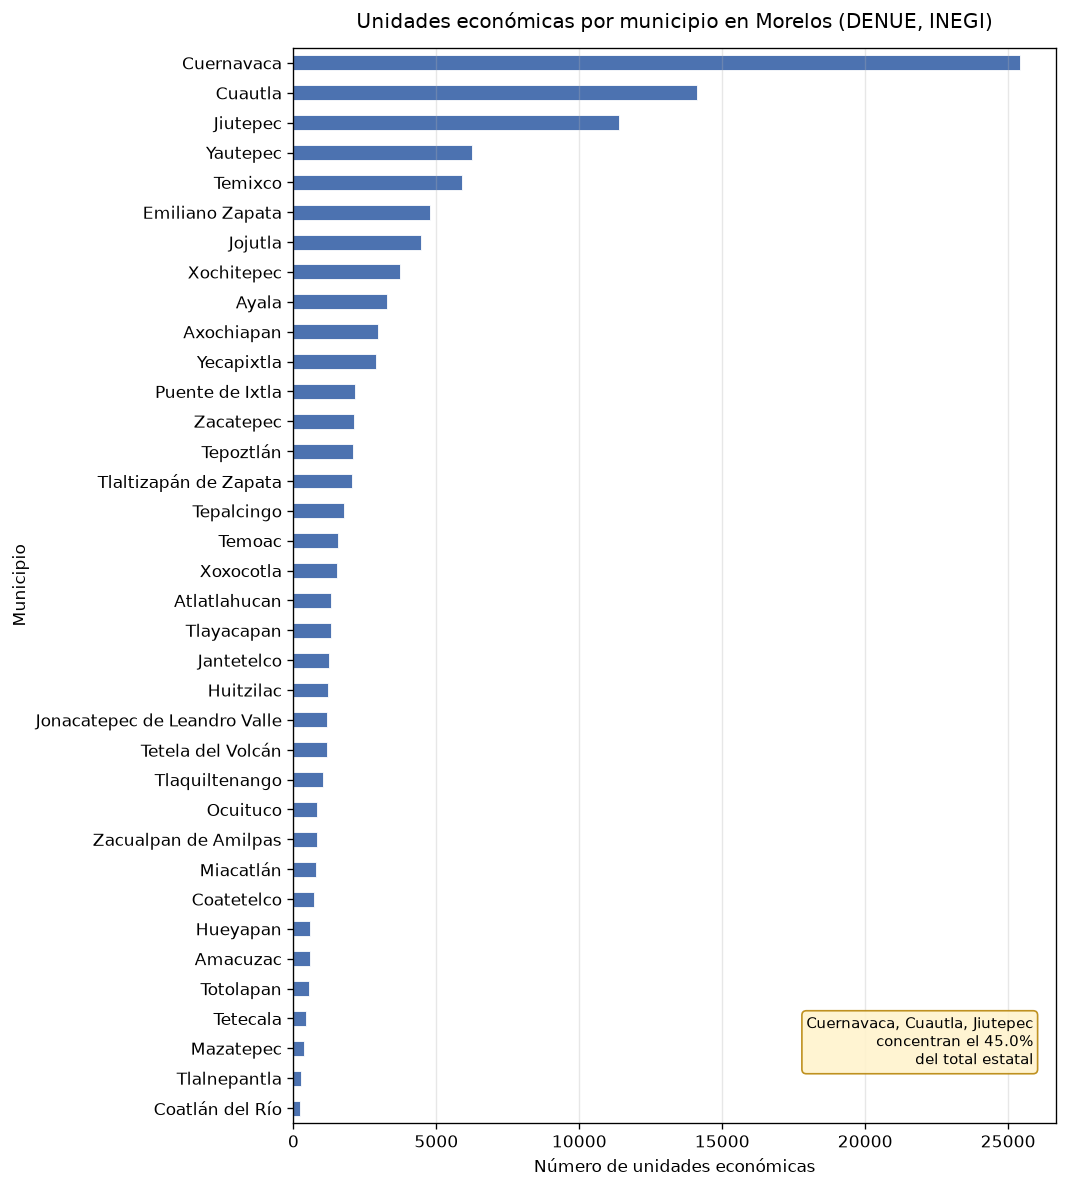

In [40]:
fig, ax = plt.subplots(figsize=(9, 10))

# Gráfica de barras horizontales: con 36 municipios las etiquetas
# solo son legibles en horizontal.
df_mun['total_unidades'].sort_values().plot(
    kind='barh', ax=ax, color='#4C72B0', edgecolor='white', linewidth=0.5
)

ax.set_title('Unidades económicas por municipio en Morelos (DENUE, INEGI)', fontsize=12, pad=12)
ax.set_xlabel('Número de unidades económicas')
ax.set_ylabel('Municipio')
ax.grid(axis='y', visible=False)

# Anotamos la concentración: es el argumento de la gráfica
top3 = df_mun['total_unidades'].sort_values(ascending=False).head(3)
concentracion = top3.sum() / df_mun['total_unidades'].sum() * 100
ax.text(0.97, 0.05,
        f'{", ".join(top3.index)}\nconcentran el {concentracion:.1f}%\ndel total estatal',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#FFF3CD', edgecolor='#B8860B', alpha=0.9))

plt.tight_layout()
RUTA_IMAGENES.mkdir(parents=True, exist_ok=True)
plt.savefig(RUTA_IMAGENES / 'grafica_1_unidades_por_municipio.png', bbox_inches='tight')
plt.show()

**¿Qué estamos viendo y por qué importa?**

La distribución es extremadamente desigual: Cuernavaca, Cuautla y Jiutepec concentran el 45% de
todas las unidades económicas del estado, mientras que Coatlán del Río tiene 235 y Tlalnepantla 263.
Cuernavaca sola tiene 108 veces más establecimientos que Coatlán del Río.

**Por qué importa para el modelo:** esta gráfica es la justificación empírica de la decisión de la
sección 9. Si alimentáramos KMeans con estos conteos absolutos, la distancia euclidiana entre
Cuernavaca y cualquier otro municipio sería enorme, y el algoritmo agruparía por tamaño, no por
perfil. Los grupos resultantes serían triviales ("grandes / medianos / chicos") y no responderían
la pregunta guía. Por eso el modelo trabaja con porcentajes.

### Gráfica 2 — Composición sectorial de cada municipio

Cómo se reparte el 100% de las unidades económicas de cada municipio entre los 8 grupos de sector. Ordenamos por porcentaje de comercio al por menor para que se aprecie el rango.

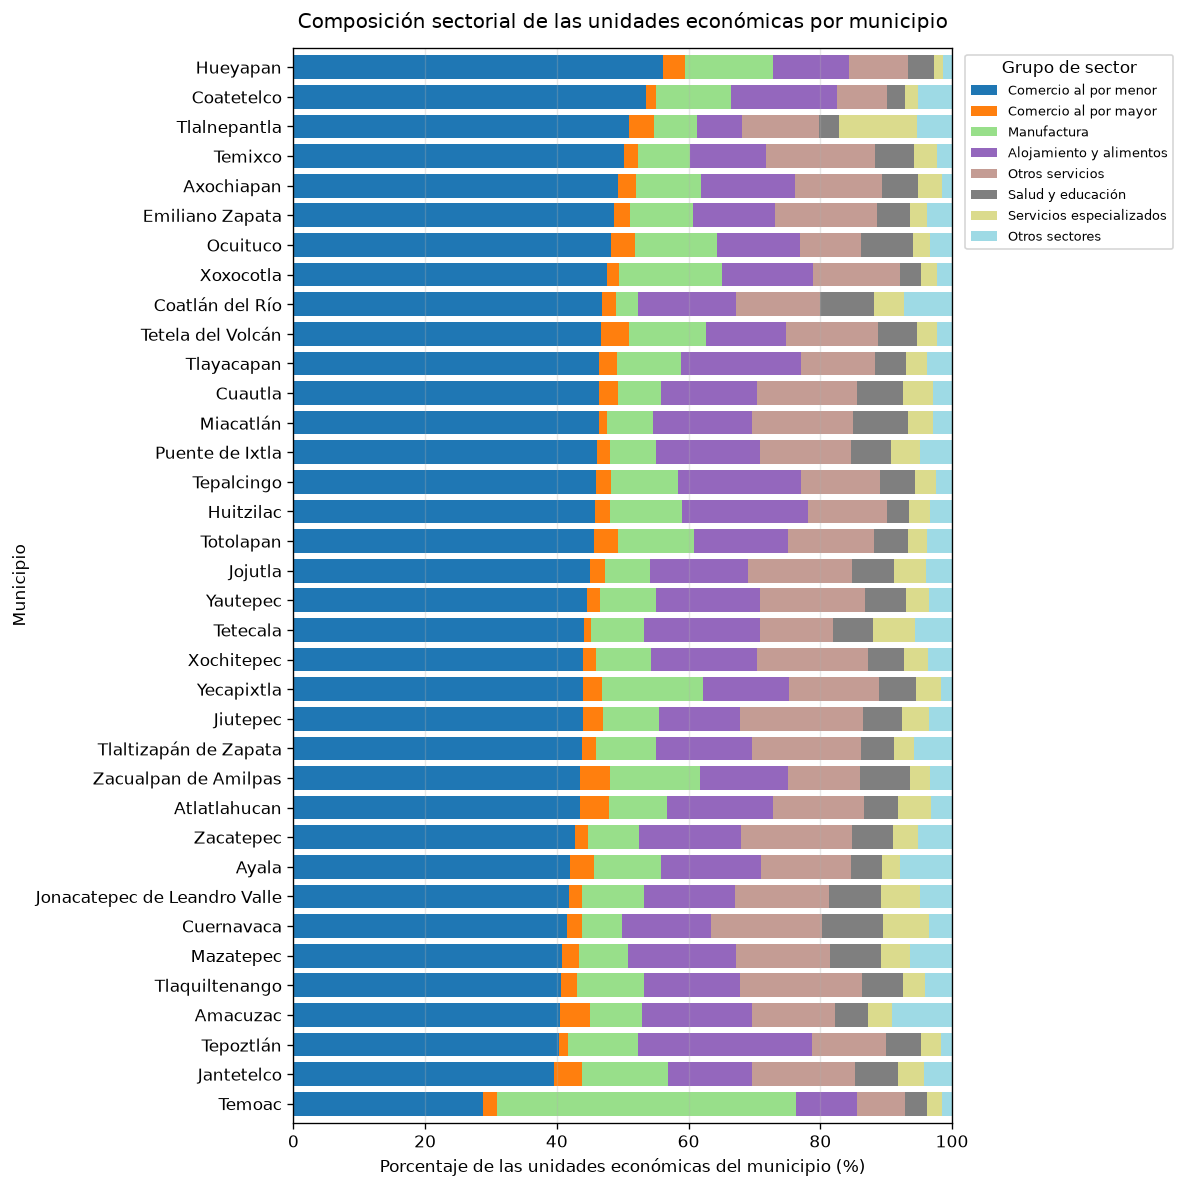

In [41]:
fig, ax = plt.subplots(figsize=(10, 10))

columnas_pct = ['pct_' + c for c in orden_grupos]

# Barras apiladas al 100%: es la forma directa de comparar COMPOSICIÓN
# entre unidades de tamaños muy distintos.
# rename(): la leyenda debe leerse sin conocer los nombres internos.
df_mun.sort_values('pct_com_menor')[columnas_pct].rename(columns=NOMBRES_VARS).plot(
    kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.8
)

ax.set_title('Composición sectorial de las unidades económicas por municipio',
             fontsize=12, pad=12)
ax.set_xlabel('Porcentaje de las unidades económicas del municipio (%)')
ax.set_ylabel('Municipio')
ax.set_xlim(0, 100)
ax.grid(axis='y', visible=False)
ax.legend(title='Grupo de sector', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'grafica_2_composicion_sectorial.png', bbox_inches='tight')
plt.show()

**¿Qué estamos viendo y por qué importa?**

Tres lecturas:

1. **El comercio al por menor domina en 35 de los 36 municipios** (entre 28.8% y 56.2%).
   La única excepción es Temoac, donde la manufactura (45.3%) supera al comercio al por menor
   (28.8%) — y ese 28.8% del rango es precisamente el suyo. Salvo ese caso, no es una variable
   que distinga por sí sola: todos los municipios tienen mucho comercio.
2. **La diferencia está en el margen.** Los casos visibles son Temoac, con una franja de manufactura
   desproporcionada (45.3% contra 10.5% de media estatal), y Tepoztlán, con la franja de alojamiento
   y alimentos más ancha del estado (26.4% contra 14.7%).
3. **La señal existe pero es sutil.** Salvo Temoac, las barras se parecen bastante entre sí. Esto
   anticipa que los grupos que encuentre KMeans van a estar separados por diferencias de pocos
   puntos porcentuales, no por contrastes dramáticos — y por lo tanto que la silhouette será baja.

Es exactamente el tipo de estructura fina que un modelo de agrupamiento sirve para detectar y que
sería muy difícil ver a simple vista en 36 municipios × 8 sectores.

In [42]:
# Tabla complementaria: los extremos de las variables más informativas.
# Sirve para poner nombre y apellido a lo que se ve en la gráfica 2.
for variable in ['pct_manufactura', 'pct_aloj_alim', 'pct_com_menor']:
    print('=' * 60)
    print(variable, ' | media estatal:', round(df_mun[variable].mean(), 2), '%')
    print('  TOP 5:')
    print(df_mun[variable].sort_values(ascending=False).head(5).round(2).to_string())
    print('  BOTTOM 5:')
    print(df_mun[variable].sort_values().head(5).round(2).to_string())
    print()

pct_manufactura  | media estatal: 10.54 %
  TOP 5:
municipio
Temoac                  45.33
Xoxocotla               15.67
Yecapixtla              15.25
Zacualpan de Amilpas    13.59
Hueyapan                13.36
  BOTTOM 5:
municipio
Coatlán del Río    3.40
Cuernavaca         6.09
Tlalnepantla       6.46
Cuautla            6.48
Jojutla            6.94

pct_aloj_alim  | media estatal: 14.72 %
  TOP 5:
municipio
Tepoztlán     26.36
Huitzilac     19.08
Tepalcingo    18.66
Tlayacapan    18.29
Tetecala      17.59
  BOTTOM 5:
municipio
Tlalnepantla          6.84
Temoac                9.35
Temixco              11.64
Hueyapan             11.64
Tetela del Volcán    12.19

pct_com_menor  | media estatal: 44.89 %
  TOP 5:
municipio
Hueyapan        56.16
Coatetelco      53.54
Tlalnepantla    50.95
Temixco         50.19
Axochiapan      49.27
  BOTTOM 5:
municipio
Temoac            28.76
Jantetelco        39.63
Tepoztlán         40.29
Amacuzac          40.49
Tlaquiltenango    40.61



---
## 11. Selección de variables y escalado

### Las 9 variables del modelo

**Composición sectorial (7):**
`pct_com_menor`, `pct_com_mayor`, `pct_manufactura`, `pct_aloj_alim`, `pct_otros_serv`,
`pct_salud_educ`, `pct_serv_espec`

**Estructura de los establecimientos (2):**
`tam_prom_unidad`, `pct_semifijo`

### Correspondencia con la pregunta de investigación

La pregunta habla de tres familias de actividad: manufactura, comercio y servicios. Las 7 variables
de composición las cubren por completo, con el nivel de detalle que el DENUE permite:

| Familia de la pregunta | Variables del modelo | % estatal |
|---|---|---|
| **Manufactura** | `pct_manufactura` | 8.8 |
| **Comercio** | `pct_com_menor` + `pct_com_mayor` | 46.9 |
| **Servicios** | `pct_aloj_alim` + `pct_otros_serv` + `pct_salud_educ` + `pct_serv_espec` | 40.7 |

No usamos una sola variable por familia porque eso borraría lo que más distingue a los municipios:
"servicios" agrupa desde una fonda hasta un despacho contable, y esa diferencia es justo la señal.
Por eso el comercio se separa en menor/mayor y los servicios en cuatro tipos.

### Justificación de las tres decisiones

**1. ¿Por qué se excluye `pct_otros_grupo`?**
Porque los porcentajes de un municipio suman 100: es un dato composicional. Si conocemos siete
de los ocho grupos, el octavo queda determinado, es información redundante. Incluirlo le daría
peso doble a esa dimensión. Dejamos fuera el grupo residual porque es el menos interpretable
(mezcla agricultura, minería, gobierno y transporte). Aun así, las variables restantes siguen sin ser
independientes entre sí, y eso se declara en limitaciones.

**2. ¿Por qué no entra `total_unidades`?**
Es la variable que mide tamaño, no perfil. Se conserva solo para describir los grupos una vez formados.

**3. ¿Por qué sí entran `tam_prom_unidad` y `pct_semifijo`?**
Porque dos municipios pueden tener la misma composición sectorial y economías muy distintas: uno de
establecimientos grandes y formales, otro de changarros y puestos semifijos. Estas dos variables
capturan esa diferencia estructural que la composición sectorial por sí sola no ve.

In [43]:
# Lista explícita de las variables del modelo. Todo lo demás en df_mun
# es descriptivo y NO se le da al algoritmo.
VARS = [
    'pct_com_menor', # comercio al por menor
    'pct_com_mayor', # comercio al por mayor / abasto
    'pct_manufactura', # manufactura
    'pct_aloj_alim', # alojamiento y alimentos (proxy de turismo)
    'pct_otros_serv', # servicios personales
    'pct_salud_educ', # salud y educación
    'pct_serv_espec', # servicios especializados
    'tam_prom_unidad', # tamaño promedio del establecimiento
    'pct_semifijo', # % de establecimientos semifijos
]

X = df_mun[VARS]
print('Matriz del modelo:', X.shape, '-> 36 municipios x 9 variables')

Matriz del modelo: (36, 9) -> 36 municipios x 9 variables


In [44]:
# Evidencia de por qué el escalado es obligatorio:
# comparar la media y la desviación de las 9 variables.
print('Antes de escalar:')
print(X.describe().loc[['mean', 'std', 'min', 'max']].round(2).to_string())

Antes de escalar:
      pct_com_menor  pct_com_mayor  pct_manufactura  pct_aloj_alim  pct_otros_serv  pct_salud_educ  pct_serv_espec  tam_prom_unidad  pct_semifijo
mean          44.89           2.68            10.54          14.72           13.60            5.75            3.88             4.43          2.51
std            4.60           0.95             6.53           3.17            2.81            1.57            1.80             0.65          1.88
min           28.76           1.11             3.40           6.84            7.22            2.83            1.37             3.53          0.00
max           56.16           4.54            45.33          26.36           18.64            9.36           11.79             6.52          7.66


**Por qué hay que escalar.** En la tabla de arriba, `pct_com_menor` ronda 45 y `tam_prom_unidad` ronda 4.4.
KMeans agrupa usando **distancia euclidiana**: sin escalar, una diferencia de 5 puntos en comercio al por
menor pesaría lo mismo que una diferencia de 5 personas por establecimiento, que en esa variable es
enorme. En la práctica, el comercio al por menor dominaría la distancia y las demás variables serían
casi irrelevantes.

`StandardScaler` deja todas las variables con media 0 y desviación 1, de modo que cada una aporta
lo mismo a la distancia.

In [45]:
# StandardScaler: (valor - media) / desviación estándar, columna por columna
escalador = StandardScaler()
X_scaled = escalador.fit_transform(X)

# Verificamos el resultado del escalado
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=VARS)
print('DESPUÉS DE ESCALAR')
print(X_scaled_df.describe().loc[['mean', 'std', 'min', 'max']].round(2).to_string())

DESPUÉS DE ESCALAR
      pct_com_menor  pct_com_mayor  pct_manufactura  pct_aloj_alim  pct_otros_serv  pct_salud_educ  pct_serv_espec  tam_prom_unidad  pct_semifijo
mean           0.00          -0.00            -0.00           0.00           -0.00           -0.00           -0.00            -0.00          0.00
std            1.01           1.01             1.01           1.01            1.01            1.01            1.01             1.01          1.01
min           -3.55          -1.67            -1.11          -2.52           -2.30           -1.89           -1.42            -1.40         -1.35
max            2.48           1.98             5.41           3.73            1.82            2.33            4.46             3.23          2.77


In [46]:
# Matriz de correlación entre las 9 variables del modelo.
# La revisamos para anticipar la pregunta sobre redundancia entre variables.
correlacion = X.corr().round(2)
correlacion

,pct_com_menor,pct_com_mayor,pct_manufactura,pct_aloj_alim,pct_otros_serv,pct_salud_educ,pct_serv_espec,tam_prom_unidad,pct_semifijo
pct_com_menor,1.00,-0.01,-0.51,-0.13,-0.12,-0.19,0.01,-0.16,0.11
pct_com_mayor,-0.01,1.00,0.03,-0.36,-0.09,-0.02,0.05,-0.31,-0.09
pct_manufactura,-0.51,0.03,1.00,-0.28,-0.49,-0.38,-0.36,-0.41,-0.24
pct_aloj_alim,-0.13,-0.36,-0.28,1.00,-0.05,0.04,-0.25,0.05,0.28
pct_otros_serv,-0.12,-0.09,-0.49,-0.05,1.00,0.42,0.18,0.55,-0.14
pct_salud_educ,-0.19,-0.02,-0.38,0.04,0.42,1.00,0.18,0.45,0.08
pct_serv_espec,0.01,0.05,-0.36,-0.25,0.18,0.18,1.00,0.45,0.22
tam_prom_unidad,-0.16,-0.31,-0.41,0.05,0.55,0.45,0.45,1.00,0.24
pct_semifijo,0.11,-0.09,-0.24,0.28,-0.14,0.08,0.22,0.24,1.00


**Lectura de la matriz de correlación.** Las correlaciones más fuertes son:

- `pct_manufactura` - `pct_com_menor`: −0.51. Es el efecto composicional esperado - si un municipio
  dedica mucho a manufactura, necesariamente le queda menos porcentaje para comercio.
- `tam_prom_unidad` - `pct_otros_serv`: +0.55, y `pct_salud_educ`: +0.45. Los municipios con
  más servicios tienden a tener establecimientos más grandes.

Ninguna pasa de |0.55|, así que no hay dos variables que digan literalmente lo mismo y no eliminamos
ninguna. Pero las correlaciones no son cero, y esa dependencia parcial es inherente a los datos
composicionales: se declara como limitación.

In [47]:
# Guardamos las 9 variables del modelo como evidencia reproducible
X.round(4).to_csv(RUTA_OUTPUTS / 'variables_modelo.csv', encoding='utf-8')
print('Guardado: outputs/variables_modelo.csv', X.shape)

Guardado: outputs/variables_modelo.csv (36, 9)


---
## 12. Elección del número de grupos (k)

KMeans exige que le digamos cuántos grupos buscar. Evaluamos k = 2 … 8 con dos criterios:

- Inercia (método del codo): suma de distancias al cuadrado de cada municipio a su centroide.
  Siempre baja al aumentar k, así que buscamos el punto donde deja de bajar rápido.
- Silhouette: de −1 a 1. Mide qué tan bien separado está cada municipio de los grupos vecinos.
  Más alto es mejor.

### Regla de decisión (declarada ANTES de ver los resultados)

Tomamos el k con mejor silhouette. Si los dos criterios apuntan a k distintos, rompemos el empate
con el codo y con la interpretabilidad de los grupos, y lo decimos explícitamente — nunca
justificando el k después de haber visto qué grupos salieron.

`random_state=42` y `n_init=10` fijos en todas las corridas, para que el resultado sea reproducible.

In [48]:
# Probamos k = 2 a 8 y guardamos las dos métricas de cada corrida.
# n_init=10: KMeans se inicializa 10 veces y se queda con la mejor solución,
# lo que reduce (no elimina) la sensibilidad a la inicialización aleatoria.
resultados_k = []

for k in range(2, 9):
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_k = modelo_k.fit_predict(X_scaled)
    resultados_k.append({
        'k': k,
        'inercia': round(modelo_k.inertia_, 2),
        'silhouette': round(silhouette_score(X_scaled, etiquetas_k), 4),
        'tamanos': str(sorted(pd.Series(etiquetas_k).value_counts().tolist(), reverse=True)),
    })

metricas_k = pd.DataFrame(resultados_k)

# Δ inercia: cuánto baja la inercia al pasar de k-1 a k. El "codo" es donde
# esta caída se vuelve pequeña.
metricas_k['delta_inercia'] = metricas_k['inercia'].diff().round(2)

metricas_k

,k,inercia,silhouette,tamanos,delta_inercia
0,2,260.76,0.1823,"[18, 18]",NaN
1,3,223.30,0.2989,"[31, 4, 1]",-37.46
2,4,178.42,0.2074,"[17, 11, 7, 1]",-44.88
3,5,153.01,0.1756,"[14, 11, 9, 1, 1]",-25.41
4,6,120.07,0.2033,"[14, 9, 7, 4, 1, 1]",-32.94
5,7,108.57,0.1734,"[14, 6, 6, 5, 3, 1, 1]",-11.50
6,8,92.83,0.1892,"[14, 7, 6, 3, 3, 1, 1, 1]",-15.74


In [49]:
# Guardamos las métricas como evidencia de que el k se eligió con números
metricas_k.to_csv(RUTA_OUTPUTS / 'metricas_k.csv', index=False, encoding='utf-8')
print('Guardado: outputs/metricas_k.csv')

Guardado: outputs/metricas_k.csv


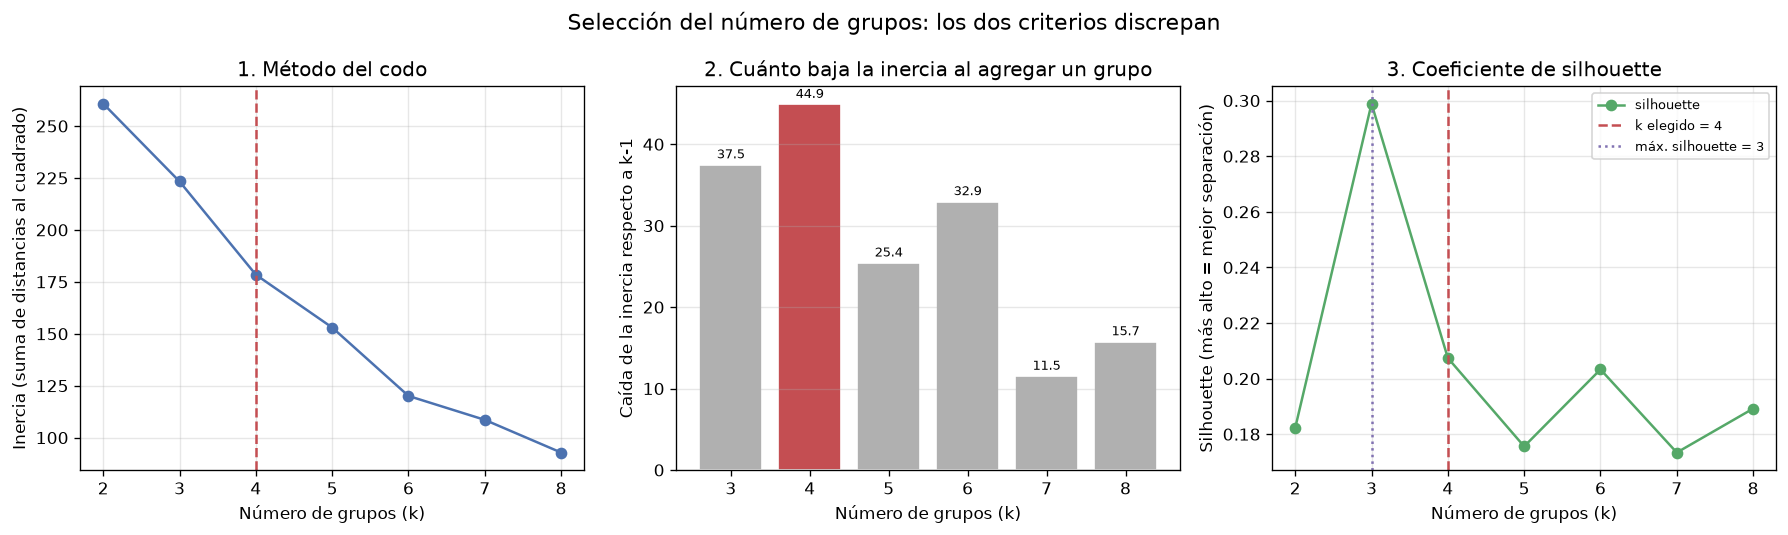

In [50]:
# k elegido. Se define aquí, en una sola variable, para que todo lo que sigue
# dependa de ella y no haya números "4" escritos a mano por el notebook.
K_ELEGIDO = 4
k_mejor_sil = int(metricas_k.loc[metricas_k['silhouette'].idxmax(), 'k'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: método del codo
metricas_k.plot(x='k', y='inercia', marker='o', ax=axes[0], legend=False, color='#4C72B0')
axes[0].set_title('1. Método del codo')
axes[0].set_xlabel('Número de grupos (k)')
axes[0].set_ylabel('Inercia (suma de distancias al cuadrado)')
axes[0].axvline(K_ELEGIDO, color='#C44E52', linestyle='--', linewidth=1.5)

# Panel 2: caída de la inercia
# En la curva de arriba el codo casi no se aprecia porque la caída es gradual.
# Graficando la DIFERENCIA entre k y k-1 se ve de forma directa en qué punto
# agregar un grupo deja de aportar. Así el argumento se ve, no solo se afirma.
caidas = metricas_k.dropna(subset=['delta_inercia'])
barras = axes[1].bar(caidas['k'], -caidas['delta_inercia'],
                     color=['#C44E52' if k == K_ELEGIDO else '#B0B0B0' for k in caidas['k']],
                     edgecolor='white')
axes[1].set_title('2. Cuánto baja la inercia al agregar un grupo')
axes[1].set_xlabel('Número de grupos (k)')
axes[1].set_ylabel('Caída de la inercia respecto a k-1')
axes[1].bar_label(barras, fmt='%.1f', fontsize=8, padding=2)
axes[1].grid(axis='x', visible=False)

# --- Panel 3: silhouette ---
metricas_k.plot(x='k', y='silhouette', marker='o', ax=axes[2], legend=False, color='#55A868')
axes[2].set_title('3. Coeficiente de silhouette')
axes[2].set_xlabel('Número de grupos (k)')
axes[2].set_ylabel('Silhouette (más alto = mejor separación)')
axes[2].axvline(K_ELEGIDO, color='#C44E52', linestyle='--', linewidth=1.5)

# Marcamos también el máximo de silhouette, que NO coincide con el k elegido:
# ocultarlo sería deshonesto, así que queda visible en la gráfica.
axes[2].axvline(k_mejor_sil, color='#8172B2', linestyle=':', linewidth=1.5)
axes[2].legend(['silhouette', f'k elegido = {K_ELEGIDO}',
                f'máx. silhouette = {k_mejor_sil}'], fontsize=8)

fig.suptitle('Selección del número de grupos: los dos criterios discrepan', fontsize=13)
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'grafica_3_seleccion_k.png', bbox_inches='tight')
plt.show()

In [51]:
# Dejamos por escrito, con números, la discrepancia entre los dos criterios
print('Máximo de silhouette en k =', k_mejor_sil,
      '->', metricas_k.loc[metricas_k['k'] == k_mejor_sil, 'silhouette'].values[0])
print('Mayor caída de inercia al pasar a k =',
      int(metricas_k.loc[metricas_k['delta_inercia'].idxmin(), 'k']),
      '->', metricas_k['delta_inercia'].min())
print()
print('Tamaños de los grupos en cada k:')
print(metricas_k[['k', 'silhouette', 'tamanos']].to_string(index=False))

Máximo de silhouette en k = 3 -> 0.2989
Mayor caída de inercia al pasar a k = 4 -> -44.88

Tamaños de los grupos en cada k:
 k  silhouette                   tamanos
 2      0.1823                  [18, 18]
 3      0.2989                [31, 4, 1]
 4      0.2074            [17, 11, 7, 1]
 5      0.1756         [14, 11, 9, 1, 1]
 6      0.2033       [14, 9, 7, 4, 1, 1]
 7      0.1734    [14, 6, 6, 5, 3, 1, 1]
 8      0.1892 [14, 7, 6, 3, 3, 1, 1, 1]


### Gráfica 3B — Tamaño de los grupos para cada k

**¿Qué vamos a ver?** La inercia y la silhouette miden qué tan compacta y separada queda la
solución, pero ninguna de las dos dice si los grupos resultantes son **útiles**. Esta gráfica
muestra en cuántos municipios queda cada grupo para cada valor de k, que es el argumento
concreto por el que descartamos k = 3 pese a que su silhouette es la más alta.


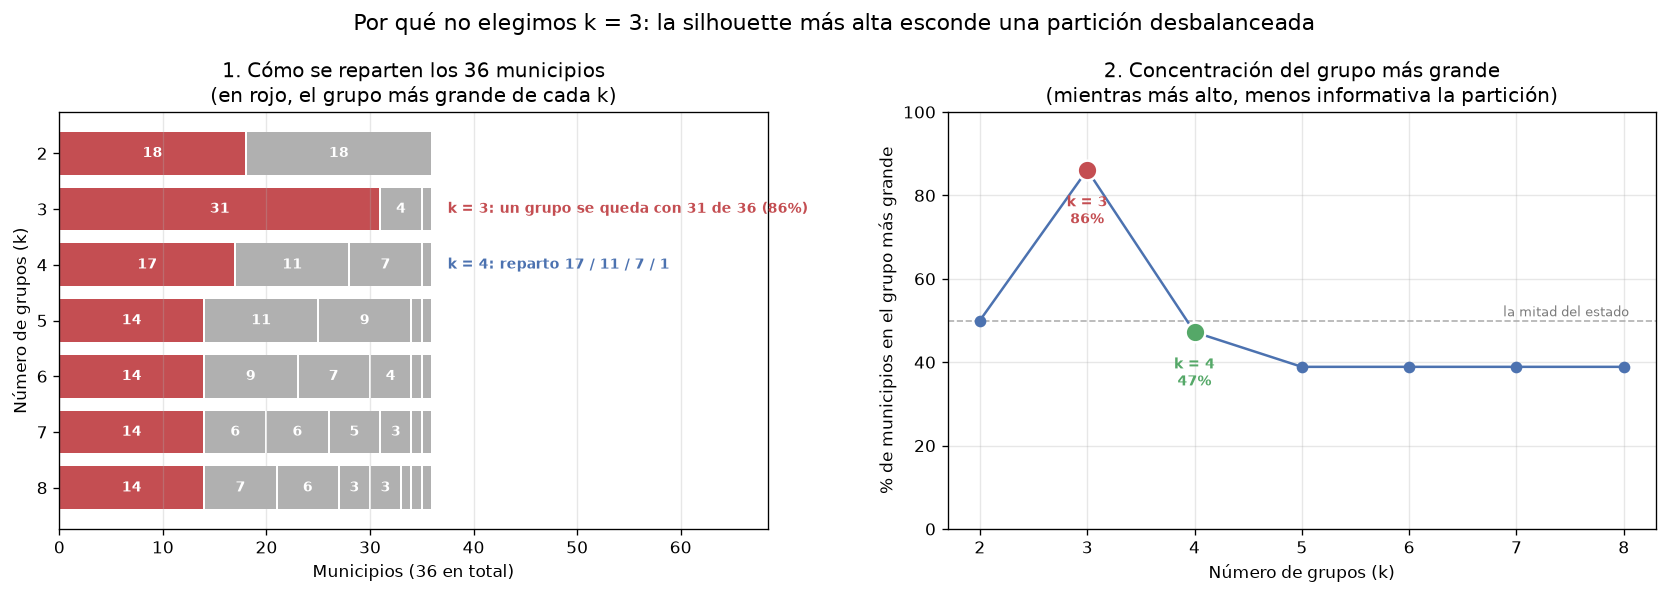

In [52]:
# Recalculamos el reparto de municipios para cada k. Misma semilla que el
# resto del notebook, así que estos tamaños son los de la tabla metricas_k.
tamanos_por_k = {}
for k in range(2, 9):
    etiquetas_tmp = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    tamanos_por_k[k] = sorted(pd.Series(etiquetas_tmp).value_counts().tolist(), reverse=True)

ks = list(tamanos_por_k)
n_mun = len(df_mun)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: barra apilada por k. El grupo mas grande va en rojo para que se
# vea de un vistazo cuanto acapara; los demas en gris.
for k in ks:
    izquierda = 0
    for posicion, tam in enumerate(tamanos_por_k[k]):
        axes[0].barh(k, tam, left=izquierda,
                     color='#C44E52' if posicion == 0 else '#B0B0B0',
                     edgecolor='white', linewidth=1.2)
        if tam >= 3:
            axes[0].text(izquierda + tam / 2, k, str(tam), ha='center', va='center',
                         fontsize=8.5, color='white', fontweight='bold')
        izquierda += tam

axes[0].set_yticks(ks)
axes[0].invert_yaxis()
axes[0].set_xlim(0, n_mun * 1.9)
axes[0].set_ylabel('Número de grupos (k)')
axes[0].set_xlabel(f'Municipios ({n_mun} en total)')
axes[0].set_title('1. Cómo se reparten los 36 municipios\n(en rojo, el grupo más grande de cada k)')
axes[0].grid(axis='y', visible=False)

# Anotamos los dos candidatos en disputa
axes[0].text(n_mun + 1.5, 3, 'k = 3: un grupo se queda con 31 de 36 (86%)',
             va='center', fontsize=8.5, color='#C44E52', fontweight='bold')
axes[0].text(n_mun + 1.5, 4, 'k = 4: reparto 17 / 11 / 7 / 1',
             va='center', fontsize=8.5, color='#4C72B0', fontweight='bold')

# Panel 2: que tanto acapara el grupo mas grande, en porcentaje.
pct_mayor = [100 * tamanos_por_k[k][0] / n_mun for k in ks]
axes[1].plot(ks, pct_mayor, marker='o', color='#4C72B0', zorder=3)
axes[1].axhline(50, color='#B0B0B0', linestyle='--', linewidth=1)
axes[1].text(8.05, 51, 'la mitad del estado', fontsize=7.5, color='#7A7A7A', ha='right')

for k, color in [(3, '#C44E52'), (4, '#55A868')]:
    pct = 100 * tamanos_por_k[k][0] / n_mun
    axes[1].scatter([k], [pct], s=140, color=color, zorder=4, edgecolor='white', linewidth=1.5)
    axes[1].annotate(f'k = {k}\n{pct:.0f}%', (k, pct), xytext=(0, -32),
                     textcoords='offset points', ha='center', fontsize=8.5,
                     color=color, fontweight='bold')

axes[1].set_xlabel('Número de grupos (k)')
axes[1].set_ylabel('% de municipios en el grupo más grande')
axes[1].set_title('2. Concentración del grupo más grande\n(mientras más alto, menos informativa la partición)')
axes[1].set_ylim(0, 100)

fig.suptitle('Por qué no elegimos k = 3: la silhouette más alta esconde una partición desbalanceada',
             fontsize=13)
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'grafica_3b_tamanos_por_k.png', bbox_inches='tight')
plt.show()


### Prueba de robustez: ¿y si Temoac fuera solo un valor atípico?

Antes de fijar k = 4 hay que responder la objeción evidente: Temoac queda solo en un grupo, así que
quizá lo correcto sería tratarlo como valor atípico, sacarlo y volver a agrupar. Lo probamos en vez
de suponerlo.


In [53]:
# Reajustamos el modelo sin Temoac, reescalando desde cero (la media y la
# desviación cambian al quitar una observación tan extrema).
X_sin_temoac = X.drop(index='Temoac')
X_sin_temoac_scaled = StandardScaler().fit_transform(X_sin_temoac)

print(f'Municipios en la prueba: {len(X_sin_temoac)} (se excluye Temoac)')
print()
print(f"{'k':>2}  {'silhouette':>10}  {'tamaños':<22}  grupo de un solo municipio")

for k in range(2, 7):
    etiquetas_sin = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_sin_temoac_scaled)
    serie = pd.Series(etiquetas_sin, index=X_sin_temoac.index)
    conteo = serie.value_counts()

    # ¿Vuelve a aparecer un grupo de un solo municipio? ¿Cuál?
    solitarios = [serie[serie == c].index[0] for c in conteo[conteo == 1].index]
    etiqueta_solitario = ', '.join(solitarios) if solitarios else '—'

    sil = silhouette_score(X_sin_temoac_scaled, etiquetas_sin)
    tam = str(sorted(conteo.tolist(), reverse=True))
    print(f'{k:>2}  {sil:>10.4f}  {tam:<22}  {etiqueta_solitario}')

print()
print(f'Referencia con los 36 municipios, k = {K_ELEGIDO}: '
      f'silhouette = {silhouette_score(X_scaled, KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10).fit_predict(X_scaled)):.4f}')


Municipios en la prueba: 35 (se excluye Temoac)

 k  silhouette  tamaños                 grupo de un solo municipio
 2      0.2081  [18, 17]                —
 3      0.1844  [17, 14, 4]             —
 4      0.2081  [17, 9, 8, 1]           Tlalnepantla
 5      0.1920  [16, 7, 6, 5, 1]        Tlalnepantla
 6      0.2175  [15, 7, 6, 4, 2, 1]     Tlalnepantla

Referencia con los 36 municipios, k = 4: silhouette = 0.2074


### Decisión: k = 4

**Los dos criterios discrepan**

| Criterio | Apunta a | Valor |
|---|---|---|
| Silhouette máxima | **k = 3** | 0.2989 |
| Mayor caída de inercia (codo) | **k = 4** | −44.88 (la mayor de toda la serie) |

1. **El codo apunta a k = 4.** En el panel 1 la curva de inercia baja de forma tan gradual que el codo
   casi no se aprecia; por eso el panel 2 grafica directamente cuánto baja la inercia en cada paso.
   Ahí se ve que la caída al pasar de 3 a 4 grupos (−44.88) es la mayor de toda la serie, y que
   ningún k posterior vuelve a alcanzarla (la mayor después de k = 4 es −32.94, en k = 6). Es decir:
   el cuarto grupo todavía explica estructura real.
2. **k = 3 produce grupos desbalanceados hasta el punto de ser poco informativos:** deja 31 de los
   36 municipios en un solo grupo. Un resultado que dice "31 municipios se parecen entre sí" no
   responde la pregunta guía. Con k = 4 los tamaños son 17 / 11 / 7 / 1.
3. **Temoac queda solo en k = 3, 4, 5, 6, 7 y 8.** No es un artefacto de haber elegido k = 4: es un
   municipio genuinamente distinto al resto.

**Problema de uso de k = 4:** la silhouette de k = 4 es 0.2074, un valor bajo. Significa
que los grupos existen pero no están nítidamente separados, algo consistente con lo que ya vimos en
la gráfica 2. Esta es una limitación real del análisis y se retoma en la sección 16.

**También probamos la alternativa obvia:** tratar a Temoac como valor atípico y excluirlo. No mejora,
y la prueba de robustez de la celda anterior lo muestra con números: la silhouette se queda
prácticamente igual (0.2074 con Temoac, 0.2081 sin él) y el problema simplemente se muda de municipio,
Tlalnepantla pasa a ser el nuevo grupo de uno. Quitar a Temoac no elimina la estructura que lo aisló;
solo esconde el caso más informativo del estado. Por eso conservamos los 36 municipios.

---
## 13. Aplicación del modelo: KMeans con k = 4

In [54]:
# Ajustamos el modelo definitivo sobre las 9 variables ESCALADAS.
modelo_kmeans = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
etiquetas = modelo_kmeans.fit_predict(X_scaled)

print('Modelo ajustado.')
print('Inercia final:', round(modelo_kmeans.inertia_, 2))
print('Silhouette final:', round(silhouette_score(X_scaled, etiquetas), 4))
print('Iteraciones:', modelo_kmeans.n_iter_)

Modelo ajustado.


Inercia final: 178.42
Silhouette final: 0.2074
Iteraciones: 4


In [55]:
# KMeans numera los grupos de forma arbitraria: el "cluster 0" de una corrida
# puede ser el "cluster 2" de otra. Los reetiquetamos ordenándolos por su
# porcentaje medio de comercio al por menor, para que la numeración sea
# estable y podamos hablar de "el cluster 0" sin ambigüedad.
df_mun['cluster'] = etiquetas

orden_clusters = df_mun.groupby('cluster')['pct_com_menor'].mean().sort_values().index
mapa_clusters = {viejo: nuevo for nuevo, viejo in enumerate(orden_clusters)}
df_mun['cluster'] = df_mun['cluster'].map(mapa_clusters)

print('Reetiquetado aplicado (orden ascendente de pct_com_menor):')
print(mapa_clusters)

Reetiquetado aplicado (orden ascendente de pct_com_menor):
{3: 0, 1: 1, 0: 2, 2: 3}


In [56]:
# Tamaño de cada grupo
print('Municipios por grupo:')
print(df_mun['cluster'].value_counts().sort_index().to_string())
print()

# Lista completa
for c in sorted(df_mun['cluster'].unique()):
    municipios_c = sorted(df_mun[df_mun['cluster'] == c].index)
    print(f'--- CLUSTER {c}  ({len(municipios_c)} municipios) ---')
    print('  ' + ', '.join(municipios_c))
    print()

Municipios por grupo:
cluster
0     1
1    17
2    11
3     7

--- CLUSTER 0  (1 municipios) ---
  Temoac

--- CLUSTER 1  (17 municipios) ---
  Coatlán del Río, Cuautla, Cuernavaca, Emiliano Zapata, Jiutepec, Jojutla, Jonacatepec de Leandro Valle, Mazatepec, Miacatlán, Puente de Ixtla, Temixco, Tetecala, Tlaltizapán de Zapata, Tlaquiltenango, Xochitepec, Yautepec, Zacatepec

--- CLUSTER 2  (11 municipios) ---
  Amacuzac, Atlatlahucan, Axochiapan, Ayala, Jantetelco, Ocuituco, Tetela del Volcán, Tlalnepantla, Totolapan, Yecapixtla, Zacualpan de Amilpas

--- CLUSTER 3  (7 municipios) ---
  Coatetelco, Hueyapan, Huitzilac, Tepalcingo, Tepoztlán, Tlayacapan, Xoxocotla



In [57]:
# Exportamos el resultado a nivel municipio.
resultados_modelo = df_mun.reset_index()[
    ['cve_geo', 'municipio', 'cluster'] + VARS + ['total_unidades']
].sort_values(['cluster', 'municipio'])

resultados_modelo.round(4).to_csv(
    RUTA_OUTPUTS / 'resultados_modelo.csv', index=False, encoding='utf-8'
)
print('Guardado: outputs/resultados_modelo.csv', resultados_modelo.shape)
resultados_modelo.head()

Guardado: outputs/resultados_modelo.csv (36, 13)


,cve_geo,municipio,cluster,pct_com_menor,pct_com_mayor,pct_manufactura,pct_aloj_alim,pct_otros_serv,pct_salud_educ,pct_serv_espec,tam_prom_unidad,pct_semifijo,total_unidades
20,17033,Temoac,0,28.755642,2.192134,45.325596,9.348807,7.221148,3.417150,2.192134,3.790458,0.838169,1551
5,17005,Coatlán del Río,1,46.808511,2.127660,3.404255,14.893617,12.765957,8.085106,4.680851,5.672340,7.659574,235
6,17006,Cuautla,1,46.382979,2.914894,6.482270,14.617021,15.212766,6.879433,4.546099,4.863050,2.943262,14100
7,17007,Cuernavaca,1,41.572193,2.298851,6.093529,13.442765,16.780822,9.356794,6.947725,6.515588,3.853724,25404
8,17008,Emiliano Zapata,1,48.663325,2.485380,9.565581,12.406015,15.497076,5.075188,2.464495,4.769424,1.294904,4788


---
## 14. Caracterización de los grupos

Se comparama la media de cada variable dentro de cada grupo contra la media estatal.

In [58]:
# Medias por grupo: es la tabla de resultados del modelo.
resumen_clusters = df_mun.groupby('cluster')[VARS + ['total_unidades']].mean().round(2)
resumen_clusters.insert(0, 'n_municipios', df_mun['cluster'].value_counts().sort_index())

# Agregamos la lista de municipios de cada grupo en una sola celda
resumen_clusters['municipios'] = (
    df_mun.reset_index().groupby('cluster')['municipio']
    .apply(lambda s: ', '.join(sorted(s)))
)

resumen_clusters.to_csv(RUTA_OUTPUTS / 'resumen_resultados.csv', encoding='utf-8')
print('Guardado: outputs/resumen_resultados.csv')
resumen_clusters[['n_municipios'] + VARS + ['total_unidades']]

Guardado: outputs/resumen_resultados.csv


,n_municipios,pct_com_menor,pct_com_mayor,pct_manufactura,pct_aloj_alim,pct_otros_serv,pct_salud_educ,pct_serv_espec,tam_prom_unidad,pct_semifijo,total_unidades
cluster,,,,,,,,,,,
0,1,28.76,2.19,45.33,9.35,7.22,3.42,2.19,3.79,0.84,1551.00
1,17,44.55,2.16,7.74,14.68,15.57,6.65,4.30,4.89,2.48,5084.29
2,11,44.90,3.85,10.99,13.38,12.88,5.63,4.19,4.09,2.32,1446.18
3,7,47.97,2.18,11.68,17.72,10.87,4.11,2.63,3.96,3.12,1310.57


In [59]:
# Desviación de cada grupo respecto a la media estatal.
# Esta es la tabla que realmente permite interpretar: dice en qué se
# diferencia cada grupo, no solo qué valores tiene.
media_estatal = df_mun[VARS].mean()
desviaciones = (df_mun.groupby('cluster')[VARS].mean() - media_estatal).round(2)

print('Media estatal de referencia:')
print(media_estatal.round(2).to_string())
print()
print('Diferencia de cada grupo respecto a la media estatal:')
desviaciones

Media estatal de referencia:
pct_com_menor      44.89
pct_com_mayor       2.68
pct_manufactura    10.54
pct_aloj_alim      14.72
pct_otros_serv     13.60
pct_salud_educ      5.75
pct_serv_espec      3.88
tam_prom_unidad     4.43
pct_semifijo        2.51

Diferencia de cada grupo respecto a la media estatal:


,pct_com_menor,pct_com_mayor,pct_manufactura,pct_aloj_alim,pct_otros_serv,pct_salud_educ,pct_serv_espec,tam_prom_unidad,pct_semifijo
cluster,,,,,,,,,
0,-16.13,-0.49,34.78,-5.38,-6.38,-2.34,-1.69,-0.64,-1.67
1,-0.33,-0.52,-2.80,-0.05,1.96,0.89,0.42,0.45,-0.03
2,0.02,1.17,0.45,-1.34,-0.72,-0.12,0.30,-0.34,-0.19
3,3.09,-0.50,1.14,2.99,-2.73,-1.65,-1.25,-0.47,0.61


### Gráfica 4 — Perfil de cada grupo

**¿Qué vamos a ver?** La diferencia de cada grupo respecto a la media estatal, variable por variable.
Las barras hacia arriba indican "este grupo tiene más de lo normal"; hacia abajo, "menos de lo normal".
Es la gráfica principal de resultados.

La dibujamos en dos paneles por una razón práctica: la desviación de Temoac en manufactura es tan
grande que, en una sola escala, deja a los otros tres grupos aplastados contra el eje y no se puede leer
nada de ellos. El panel B repite exactamente la misma información sin el cluster 0.

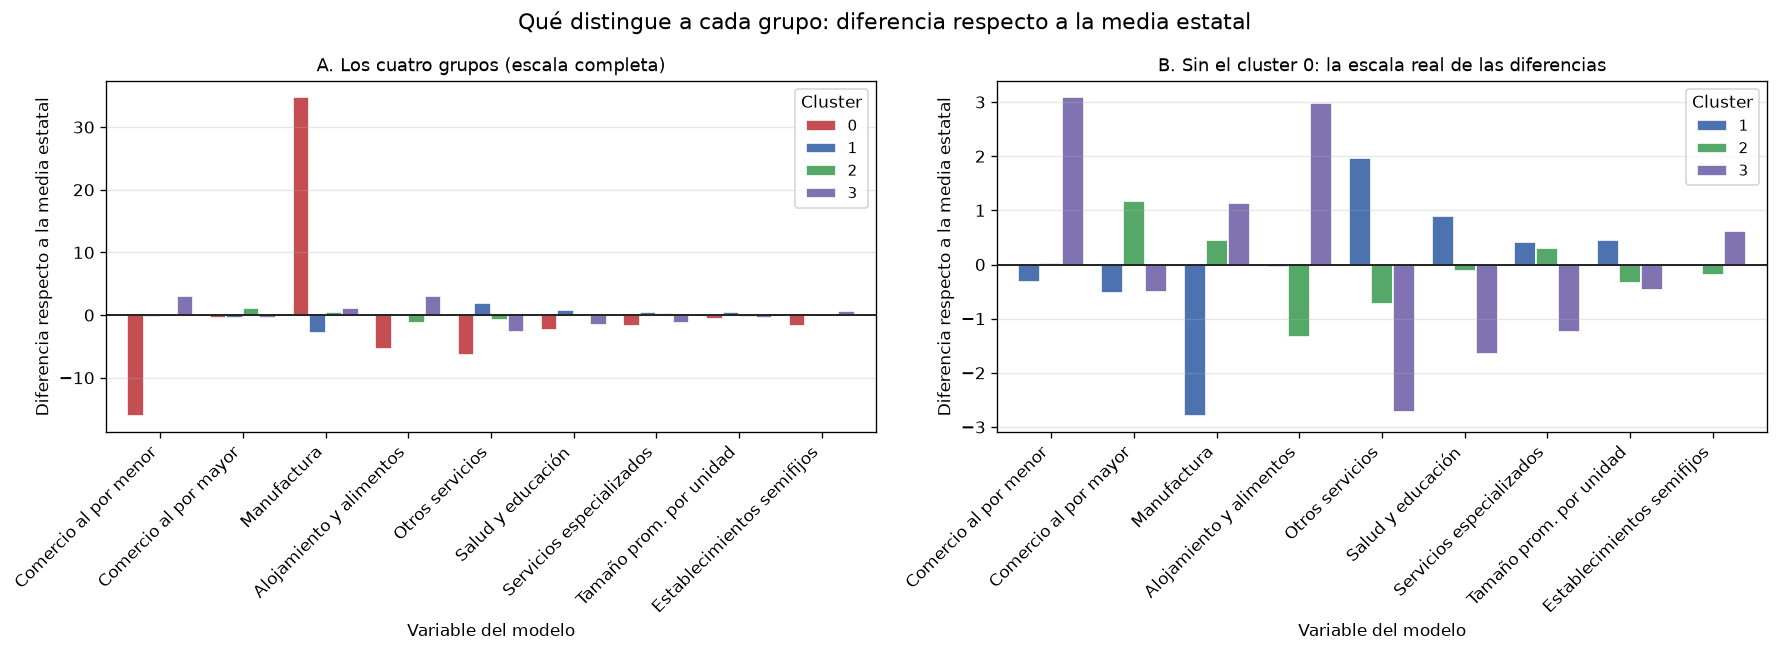

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Graficamos las DESVIACIONES y no las medias: así se ve de un vistazo
# qué distingue a cada grupo, que es justo lo que hay que interpretar.
tabla_grafica = desviaciones.rename(columns=NOMBRES_VARS).T

# --- Panel A: los cuatro grupos ---
tabla_grafica.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='white',
                   color=COLORES_CLUSTER)
axes[0].set_title('A. Los cuatro grupos (escala completa)', fontsize=11)

# Panel B: sin el cluster 0
# La barra de manufactura de Temoac (+34.8) es tan grande que aplasta a los
# otros tres grupos y los vuelve ilegibles. Repetimos la gráfica sin él para
# poder VER las diferencias sutiles, que son el resultado interesante.
tabla_grafica.drop(columns=0).plot(kind='bar', ax=axes[1], width=0.8,
                                   edgecolor='white', color=COLORES_CLUSTER[1:])
axes[1].set_title('B. Sin el cluster 0: la escala real de las diferencias', fontsize=11)

for ax in axes:
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Variable del modelo')
    ax.set_ylabel('Diferencia respecto a la media estatal')
    ax.legend(title='Cluster', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='x', visible=False)
    for etiqueta in ax.get_xticklabels():
        etiqueta.set_ha('right')

fig.suptitle('Qué distingue a cada grupo: diferencia respecto a la media estatal',
             fontsize=13)
plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'grafica_4_perfil_clusters.png', bbox_inches='tight')
plt.show()

**¿Qué estamos viendo y por qué importa?**

**Panel A** deja clara la magnitud del caso Temoac: +34.8 puntos de manufactura sobre la media
estatal. Es un contraste de un orden de magnitud distinto al de todo lo demás, y el hecho de que el
panel A sea ilegible para los otros grupos es en sí mismo el hallazgo.

**Panel B** muestra la escala real en la que se distinguen los otros tres grupos: diferencias de
1 a 3 puntos porcentuales. El cluster 1 tiene más servicios personales y de salud/educación; el
cluster 2 destaca en comercio al por mayor; el cluster 3 en comercio al por menor y alojamiento y
alimentos, con menos servicios especializados.

**Por qué importa:** esta gráfica es la evidencia de que la agrupación no es arbitraria, cada grupo
tiene un patrón propio— pero también de que **las diferencias son sutiles**, lo que explica la
silhouette baja de la sección 12. Ambas cosas hay que decirlas.

### Gráfica 5 — Los grupos vistos en dos dimensiones (PCA)

**¿Qué vamos a ver?** Las 9 variables no se pueden dibujar en una hoja. PCA las comprime a 2 ejes que
conservan la mayor variabilidad posible, y ahí coloreamos por grupo.

**Importante, el orden de las operaciones:** el modelo se ajustó sobre las 9 variables escaladas,
no sobre los componentes. PCA se usa solo para poder ver el resultado, después de agrupar.

In [61]:
# PCA a 2 componentes, únicamente para visualizar.
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_ * 100
print('Varianza explicada por PC1:', round(varianza[0], 1), '%')
print('Varianza explicada por PC2:', round(varianza[1], 1), '%')
print('Varianza acumulada:', round(varianza.sum(), 1), '%')

df_mun['pc1'] = componentes[:, 0]
df_mun['pc2'] = componentes[:, 1]

Varianza explicada por PC1: 29.7 %
Varianza explicada por PC2: 17.3 %
Varianza acumulada: 47.0 %


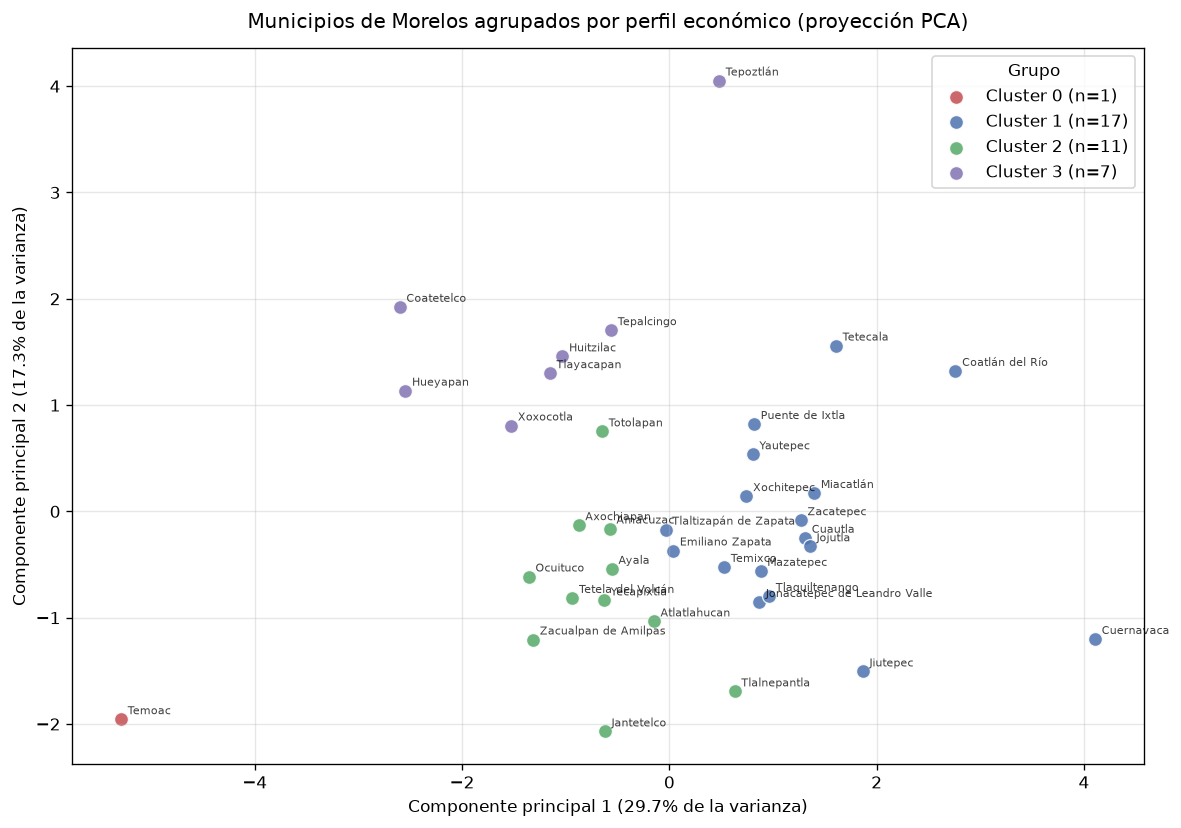

In [62]:
fig, ax = plt.subplots(figsize=(10, 7))

# Dibujamos un scatter por cluster para que cada uno tenga su color y etiqueta
for c in sorted(df_mun['cluster'].unique()):
    sub = df_mun[df_mun['cluster'] == c]
    sub.plot(kind='scatter', x='pc1', y='pc2', ax=ax,
             color=COLORES_CLUSTER[c], s=70, alpha=0.85,
             label=f'Cluster {c} (n={len(sub)})', edgecolor='white', linewidth=0.8)

# Anotamos el nombre de cada municipio: sin esto la gráfica no se puede leer
for municipio, fila in df_mun.iterrows():
    ax.annotate(municipio, (fila['pc1'], fila['pc2']),
                fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords='offset points')

ax.set_title('Municipios de Morelos agrupados por perfil económico (proyección PCA)',
             fontsize=12, pad=12)
ax.set_xlabel(f'Componente principal 1 ({varianza[0]:.1f}% de la varianza)')
ax.set_ylabel(f'Componente principal 2 ({varianza[1]:.1f}% de la varianza)')
ax.legend(title='Grupo')

plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'grafica_5_pca_clusters.png', bbox_inches='tight')
plt.show()

**¿Qué estamos viendo y por qué importa?**

**Temoac aparece completamente aislado** en un extremo del gráfico. Los otros tres grupos ocupan
regiones distintas pero con fronteras que se tocan: hay municipios en el borde que podrían haber
caído en cualquiera de dos grupos.

**Nota importante:** los dos componentes solo conservan el 47.0% de la varianza total. Es
decir, más de la mitad de la información no se ve en esta gráfica. Dos municipios que aquí se ven
cerca pueden estar lejos en las 9 dimensiones reales. Por eso esta gráfica sirve para comunicar el
resultado, no para validarlo, la validación son las métricas de la sección 12 y la tabla de
desviaciones de arriba.

### Gráfica 6 — Distribución territorial de los grupos

**¿Qué vamos a ver?** Los municipios ubicados por el centroide geográfico de sus establecimientos
(promedio de latitud y longitud), coloreados por grupo. Es un mapa aproximado que no requiere
librerías de cartografía.

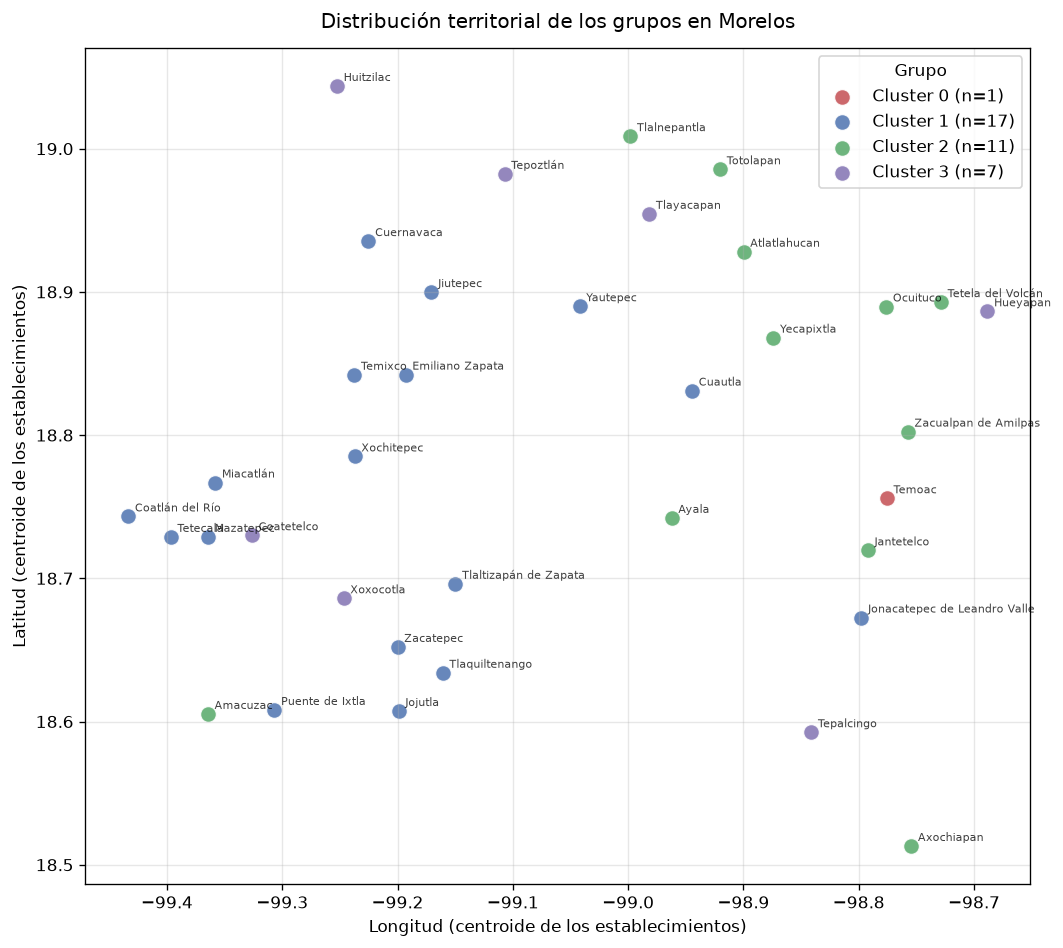

In [63]:
fig, ax = plt.subplots(figsize=(9, 8))

for c in sorted(df_mun['cluster'].unique()):
    sub = df_mun[df_mun['cluster'] == c]
    sub.plot(kind='scatter', x='lon_prom', y='lat_prom', ax=ax,
             color=COLORES_CLUSTER[c], s=90, alpha=0.85,
             label=f'Cluster {c} (n={len(sub)})', edgecolor='white', linewidth=0.8)

for municipio, fila in df_mun.iterrows():
    ax.annotate(municipio, (fila['lon_prom'], fila['lat_prom']),
                fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords='offset points')

ax.set_title('Distribución territorial de los grupos en Morelos', fontsize=12, pad=12)
ax.set_xlabel('Longitud (centroide de los establecimientos)')
ax.set_ylabel('Latitud (centroide de los establecimientos)')
ax.legend(title='Grupo')

plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'grafica_6_mapa_clusters.png', bbox_inches='tight')
plt.show()

**¿Qué estamos viendo y por qué importa?**

Esta gráfica pone a prueba la idea de "vecindarios económicos" planteada en la justificación:
¿los municipios que se parecen económicamente son también vecinos en el mapa?

La respuesta es: parcialmente. Se alcanza a distinguir cierta lógica territorial, los municipios del
**cluster 1** se alinean sobre el corredor **Cuernavaca–Jiutepec–Yautepec–Cuautla** y las cabeceras del
sur, y buena parte del **cluster 2** se concentra en el oriente del estado, en la zona de los Altos,
pero los grupos no son territorialmente compactos. El cluster 1 incluye a Coatlán del Río y Tetecala,
en el extremo poniente, junto a Cuautla, en el oriente. Y el cluster 3 junta a Huitzilac (norte) con
Tepalcingo (sur), separados por todo el estado.

Es decir: la similitud económica no se reduce a la cercanía geográfica, que es justamente lo que
buscábamos comprobar.

**Nota importante:** esto es una descripción, no una explicación. La geografía no entró al
modelo, los grupos se formaron únicamente con composición sectorial y estructura de los
establecimientos. Que aparezca un patrón espacial parcial sugiere que perfil económico y ubicación están
relacionados, pero no permite afirmar que uno cause el otro.

---
### Gráfica 7 — Mapa de Morelos por grupo

**¿Qué vamos a ver?** El mismo resultado de la gráfica 6, pero sobre la forma real del estado.
La gráfica 6 ubica cada municipio con un punto (el centroide de sus establecimientos); esta pinta
el territorio completo, que es lo que permite ver si los grupos forman regiones contiguas.

**De dónde sale la geometría.** Los polígonos municipales vienen de OpenStreetMap, descargados con
la Overpass API en agosto de 2026 y guardados en `data/geo/morelos_municipios.geojson`. Se eligió
esa fuente porque es la única gratuita que ya incluye los **36** municipios: Xoxocotla, Coatetelco
y Hueyapan se crearon en 2017 y varios archivos de uso común todavía traen solo 33. Los polígonos
se simplificaron con el algoritmo de Ramer-Douglas-Peucker, de 33,186 a 5,942 vértices, para que
el archivo pese 125 KB en vez de varios megas.

In [64]:
# La geometria es un insumo externo: verificamos que exista y que cuadre.
import json

RUTA_GEO = BASE / 'data' / 'geo' / 'morelos_municipios.geojson'
assert RUTA_GEO.exists(), f'Falta el archivo de geometria en {RUTA_GEO}'

with open(RUTA_GEO, encoding='utf-8') as f:
    geojson_mun = json.load(f)

# La geometria y el modelo tienen que hablar de los mismos 36 municipios.
municipios_geo = {f['properties']['municipio'] for f in geojson_mun['features']}
assert municipios_geo == set(df_mun.index), (
    f'Desajuste entre geometria y modelo: {municipios_geo ^ set(df_mun.index)}')

print('Geometria cargada:', len(geojson_mun['features']), 'municipios, todos con lugar en el modelo.')

Geometria cargada: 36 municipios, todos con lugar en el modelo.


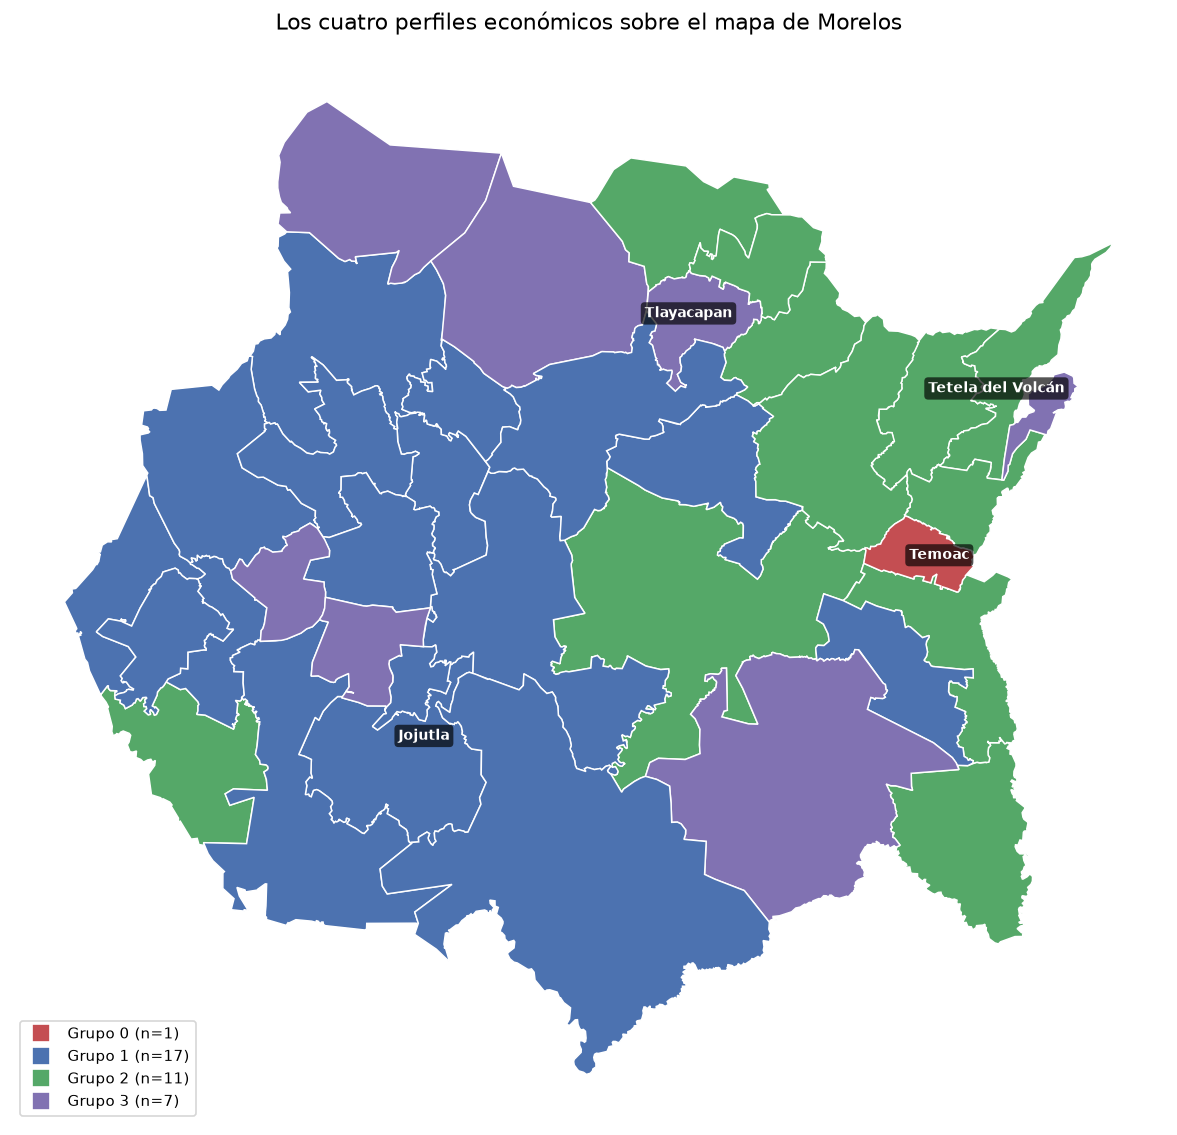

In [65]:
from matplotlib.patches import Polygon as PoligonoMPL
from matplotlib.lines import Line2D


def anillos_de(feature):
    """Devuelve los anillos exteriores de un Polygon o de un MultiPolygon."""
    g = feature['geometry']
    partes = [g['coordinates']] if g['type'] == 'Polygon' else g['coordinates']
    return [parte[0] for parte in partes]


fig, ax = plt.subplots(figsize=(10, 9.5))

for feature in geojson_mun['features']:
    municipio = feature['properties']['municipio']
    grupo = df_mun.loc[municipio, 'cluster']
    for anillo in anillos_de(feature):
        ax.add_patch(PoligonoMPL(anillo, closed=True,
                                 facecolor=COLORES_CLUSTER[grupo],
                                 edgecolor='white', linewidth=0.9))

# Etiquetamos solo al representante de cada grupo: 36 nombres encimados no se leen.
for municipio in ['Temoac', 'Jojutla', 'Tetela del Volcán', 'Tlayacapan']:
    ax.annotate(municipio,
                (df_mun.loc[municipio, 'lon_prom'], df_mun.loc[municipio, 'lat_prom']),
                fontsize=8.5, fontweight='bold', color='white', ha='center',
                bbox=dict(boxstyle='round,pad=0.28', facecolor='#000000AA', edgecolor='none'))

ax.set_aspect('equal')
ax.autoscale_view()
ax.set_axis_off()
ax.set_title('Los cuatro perfiles económicos sobre el mapa de Morelos', fontsize=13, pad=14)

ax.legend(handles=[Line2D([0], [0], marker='s', linestyle='', markersize=11,
                          markerfacecolor=COLORES_CLUSTER[c], markeredgecolor='white',
                          label=f'Grupo {c} (n={(df_mun["cluster"] == c).sum()})')
                   for c in sorted(df_mun['cluster'].unique())],
          loc='lower left', frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig(RUTA_IMAGENES / 'grafica_7_mapa_municipios.png', bbox_inches='tight', dpi=140)
plt.show()

**¿Qué estamos viendo y por qué importa?**

El modelo **nunca** recibió la ubicación de los municipios: agrupó por composición sectorial y por
estructura de los establecimientos. Que los grupos aparezcan como manchas contiguas y no salpicados
al azar es entonces un resultado, no un supuesto.

Se leen tres regiones. El grupo 1 (azul) ocupa el corredor Cuernavaca–Cuautla y baja hacia el sur
por Jojutla y Zacatepec: es el eje urbano del estado. El grupo 2 (verde) se concentra en el oriente:
10 de sus 11 municipios caen en la mitad oriental del estado, en la zona de los Altos y la falda
del Popocatépetl. La excepción es Amacuzac, en el extremo suroeste. El grupo 3 (morado) aparece
disperso, y esa dispersión es informativa: junta al norte turístico (Tepoztlán, Tlayacapan,
Huitzilac) con municipios del sur y del poniente que no tienen nada que ver con el turismo
(Tepalcingo, Xoxocotla, Coatetelco). Es la mejor evidencia visual de que KMeans agrupa por
composición y no por causa: perfiles parecidos a los que se llegó por caminos distintos.

Temoac, en rojo, es un punto minúsculo en el oriente. Todo el peso del grupo 0 cabe en ese pedazo
de mapa.

---
### Mapa interactivo

Las gráficas anteriores están congeladas en una sola lectura. Esta versión deja explorar el estado
sector por sector: se elige uno de los ocho grupos y el mapa se repinta según qué porcentaje de las
unidades económicas de cada municipio pertenece a él.

Incluye además una capa de puntos: cada uno de los 113 mil establecimientos dibujado en su latitud
y longitud reales. Donde los puntos se encinan el color se satura solo, así que los centros urbanos,
mercados y corredores comerciales aparecen sin necesidad de calcular nada. Es la misma información
que el mapa de colores, pero sin promediar por municipio.

El resultado es un archivo HTML independiente: no necesita servidor, ni internet, ni librerías
externas. Se abre con doble clic.

In [66]:
# El HTML se arma sobre una plantilla para no meter 300 lineas de CSS y
# JavaScript dentro de una celda del notebook.
RUTA_PLANTILLA = BASE / 'notebook' / 'plantilla_mapa.html'
assert RUTA_PLANTILLA.exists(), f'Falta la plantilla en {RUTA_PLANTILLA}'

ETIQUETA_GRUPO = {
    'com_menor':  'Comercio al por menor',   'com_mayor':   'Comercio al por mayor',
    'manufactura': 'Manufactura',            'aloj_alim':   'Alojamiento y alimentos',
    'otros_serv': 'Otros servicios',         'salud_educ':  'Salud y educación',
    'serv_espec': 'Servicios especializados', 'otros_grupo': 'Otros sectores',
}

# Composicion de los 8 grupos por municipio. Aqui si entra otros_grupo: se excluyo
# del MODELO por redundante, pero como capa consultable del mapa es legitima.
datos_municipios = {
    municipio: {
        'cluster': int(df_mun.loc[municipio, 'cluster']),
        'total': int(matriz_conteos.loc[municipio].sum()),
        'pct': {g: round(float(matriz_pct.loc[municipio, 'pct_' + g]), 2) for g in orden_grupos},
    }
    for municipio in df_mun.index
}
print('Datos de', len(datos_municipios), 'municipios listos para el mapa.')

Datos de 36 municipios listos para el mapa.


In [67]:
# --- Capa de puntos ---
# El DENUE trae unos pocos establecimientos con coordenadas mal capturadas (uno de
# Jojutla cae en Baja California Sur). No afectan al modelo, que nunca usa
# coordenadas, pero si romperian la escala del mapa: se excluyen solo de esta capa.
coords_geo = [p for f in geojson_mun['features'] for anillo in anillos_de(f) for p in anillo]
LON_MIN = min(p[0] for p in coords_geo); LON_MAX = max(p[0] for p in coords_geo)
LAT_MIN = min(p[1] for p in coords_geo); LAT_MAX = max(p[1] for p in coords_geo)
MARGEN = 0.02

dentro = (df_sel['longitud'].between(LON_MIN - MARGEN, LON_MAX + MARGEN) &
          df_sel['latitud'].between(LAT_MIN - MARGEN, LAT_MAX + MARGEN))
puntos = df_sel.loc[dentro, ['longitud', 'latitud', 'grupo_sector']]

print(f'Establecimientos fuera del mapa de Morelos: {(~dentro).sum()} de {len(df_sel):,}')
print(df_sel.loc[~dentro, ['municipio', 'nombre_act', 'latitud', 'longitud']].to_string(index=False))

Establecimientos fuera del mapa de Morelos: 4 de 113,066
   municipio                                                                  nombre_act   latitud    longitud
  Cuernavaca                                         Edificación de vivienda unifamiliar 28.688091 -100.534132
    Jiutepec Edificación de inmuebles comerciales y de servicios, excepto la supervisión 19.811946  -90.533817
     Jojutla                                               Elaboración de azúcar de caña 25.261288 -111.786337
Tlalnepantla                                                              Banca múltiple 19.430419  -99.193597


In [68]:
# Cada punto se codifica en 6 caracteres base 36 (3 para x, 3 para y). Con 4
# decimales la precision es de ~11 m, de sobra para un mapa de densidad, y el
# HTML pesa 0.9 MB en vez de varios megas.
ESCALA = 10_000
ORIGEN_LON, ORIGEN_LAT = LON_MIN - MARGEN, LAT_MIN - MARGEN
DIGITOS = '0123456789abcdefghijklmnopqrstuvwxyz'


def a_base36(n):
    return DIGITOS[(n // 1296) % 36] + DIGITOS[(n // 36) % 36] + DIGITOS[n % 36]


xs = ((puntos['longitud'] - ORIGEN_LON) * ESCALA).round().astype(int)
ys = ((puntos['latitud'] - ORIGEN_LAT) * ESCALA).round().astype(int)
assert xs.between(0, 36**3 - 1).all() and ys.between(0, 36**3 - 1).all(), 'Coordenada fuera de rango'

indice_grupo = {g: i for i, g in enumerate(orden_grupos)}
datos_mapa = {
    'geo': geojson_mun,
    'mun': datos_municipios,
    'orden': orden_grupos,
    'etiqueta': ETIQUETA_GRUPO,
    'puntos': {
        'blob': ''.join(a_base36(x) + a_base36(y) for x, y in zip(xs, ys)),
        'sect': ''.join(str(indice_grupo[g]) for g in puntos['grupo_sector']),
        'lon0': ORIGEN_LON, 'lat0': ORIGEN_LAT, 'esc': ESCALA, 'n': len(puntos),
    },
}

html = RUTA_PLANTILLA.read_text(encoding='utf-8').replace(
    '/*__DATOS__*/', json.dumps(datos_mapa, ensure_ascii=False, separators=(',', ':')))

RUTA_MAPA = RUTA_OUTPUTS / 'mapa_interactivo.html'
RUTA_MAPA.write_text(html, encoding='utf-8')

print(f'Guardado: {RUTA_MAPA.relative_to(BASE)} '
      f'({RUTA_MAPA.stat().st_size / 1024 / 1024:.2f} MB)')
print(f'Puntos embebidos : {len(puntos):,}')
print(f'Capas del mapa   : grupos del modelo + {len(orden_grupos)} sectores + puntos')

Guardado: outputs\mapa_interactivo.html (0.90 MB)
Puntos embebidos : 113,062
Capas del mapa   : grupos del modelo + 8 sectores + puntos


In [69]:
# "Municipio típico": el más cercano al centroide de su grupo en el espacio
# escalado de 9 dimensiones. Es el mejor representante de cada grupo y sirve
# para explicar cada cluster en pocos segundos durante la exposición.
print('MUNICIPIO MÁS REPRESENTATIVO DE CADA GRUPO')
print('(el más cercano al centro de su propio grupo)')
print()

for c in sorted(df_mun['cluster'].unique()):
    miembros = X_scaled_df[df_mun['cluster'] == c]
    centro = miembros.mean()
    distancias = ((miembros - centro) ** 2).sum(axis=1) ** 0.5
    print(f'  Cluster {c} (n={len(miembros)}): {distancias.idxmin()}')

MUNICIPIO MÁS REPRESENTATIVO DE CADA GRUPO
(el más cercano al centro de su propio grupo)

  Cluster 0 (n=1): Temoac
  Cluster 1 (n=17): Jojutla
  Cluster 2 (n=11): Tetela del Volcán
  Cluster 3 (n=7): Tlayacapan


---
## 15. Interpretación de los resultados

### Cluster 0 — El caso especializado: manufactura de confitería
**1 municipio:** Temoac. **Representante:** Temoac.

Se diferencia del resto de forma abrumadora por una sola variable: 45.3% de sus unidades económicas
son manufactura, contra una media estatal de 10.5% (+34.8 puntos). A cambio tiene menos comercio
al por menor (−16.1) y menos servicios personales (−6.4) de lo normal.

Al revisar el detalle, 592 de sus 1,551 establecimientos, el 38% del municipio, corresponden a una
sola actividad: "Elaboración de dulces, chicles y productos de confitería que no sean de chocolate".
Esto es consistente con la conocida especialización de la región de Temoac en la producción de dulces
tradicionales.

Es el único grupo donde la especialización es tan marcada que el municipio no se parece a ningún otro del estado.

---

### Cluster 1 — Perfil de servicios y establecimientos más grandes
**17 municipios:** Coatlán del Río, Cuautla, Cuernavaca, Emiliano Zapata, Jiutepec, Jojutla,
Jonacatepec de Leandro Valle, Mazatepec, Miacatlán, Puente de Ixtla, Temixco, Tetecala,
Tlaltizapán de Zapata, Tlaquiltenango, Xochitepec, Yautepec y Zacatepec.
**Representante:** Jojutla.

Se diferencia principalmente por tener más servicios de lo normal: servicios personales (+2.0),
salud y educación (+0.9) y servicios especializados (+0.4); y menos manufactura (−2.8). Además sus
establecimientos son en promedio más grandes (4.89 personas estimadas por unidad contra 4.43 estatal).

Es el grupo con diferencia más poblado de establecimientos: 5,084 unidades en promedio por municipio,
contra 1,300-1,500 de los otros grupos. Concentra las tres ciudades principales del estado y las
cabeceras regionales del sur.

Los resultados sugieren que se trata de las economías urbanas y de cabecera, donde además del
comercio de siempre existe una oferta de servicios que requiere una población concentrada para
sostenerse.

---

### Cluster 2 — Comercio de abasto y manufactura ligera del oriente
**11 municipios:** Amacuzac, Atlatlahucan, Axochiapan, Ayala, Jantetelco, Ocuituco,
Tetela del Volcán, Tlalnepantla, Totolapan, Yecapixtla y Zacualpan de Amilpas.
**Representante:** Tetela del Volcán.

Se diferencia sobre todo por el comercio al por mayor: 3.85% contra 2.68% estatal (+1.2 puntos,
la desviación más alta de los cuatro grupos en esa variable). Tiene además algo más de manufactura
(+0.5) y menos servicios personales (−0.7), menos alojamiento y alimentos (−1.3) y establecimientos
más pequeños que el promedio (4.09 contra 4.43).

Con los datos disponibles se observa que es un perfil de economía local de abasto: municipios
predominantemente rurales del oriente del estado, con una función de intermediación comercial hacia su
entorno y sin la oferta de servicios de las cabeceras.

---

### Cluster 3 — Consumo final: comercio al por menor y alimentos
**7 municipios:** Coatetelco, Hueyapan, Huitzilac, Tepalcingo, Tepoztlán, Tlayacapan y Xoxocotla.
**Representante:** Tlayacapan.

Se diferencia por concentrar sus unidades económicas en consumo directo: comercio al por menor
(+3.1) y alojamiento y alimentos (+3.0), las dos desviaciones positivas más grandes fuera de Temoac.
Juntas suman 65.7% de sus unidades, contra 59.6% de media estatal. En contrapartida, es el grupo con
menos servicios especializados (−1.3) y menos salud y educación (−1.7), y con la mayor proporción
de establecimientos semifijos (+0.6).

**Observación:** mezcla municipios de vocación turística reconocida
(Tepoztlán, Tlayacapan, Huitzilac) con municipios rurales de fuerte identidad comunitaria (Hueyapan,
Coatetelco, Xoxocotla). El modelo los agrupa porque su composición de unidades económicas se parece,
no porque tengan la misma causa: en Tepoztlán el peso de alimentos y hospedaje viene del visitante, y en
Hueyapan el peso del comercio al por menor viene del abasto cotidiano local. KMeans agrupa por
composición, no por causa.

---
## 16. Limitaciones

Reconocer hasta dónde llega el análisis es parte del análisis.

### Sobre los datos

1. **El DENUE cuenta establecimientos, no economía.** Registra que un negocio existe y a qué se dedica,
   pero no su facturación, márgenes de ingreso ni valor agregado. Un taller familiar y una planta
   industrial cuentan como uno cada uno. Un municipio con pocas unidades grandes puede tener más
   actividad económica real que uno con muchas unidades pequeñas, y este análisis no lo vería.
   Es la limitación declarada desde el planteamiento (sección 0.1, punto 4): las conclusiones se acotan
   a la composición estructural del mercado formal.

2. **`per_ocu` es un rango, no un conteo.** `tam_prom_unidad` se construyó asignándole a cada rango un
   punto medio elegido por nosotros. Es una aproximación, no empleo medido.
   El último rango es abierto, así que el 300 es un supuesto: si las unidades muy grandes
   fueran mucho mayores, subestimaríamos el tamaño de los municipios que las tienen.

3. **Corte temporal único (DENUE 2026/06).** Es una fotografía, no una película. No podemos hacer
   ninguna afirmación sobre evolución, crecimiento o tendencias: no sabemos si el perfil de un municipio
   es estable o si cambió recientemente.

4. **Sesgo de captura.** El DENUE cubre establecimientos registrados con domicilio identificable. La
   actividad informal ambulante y el trabajo desde el hogar quedan subrepresentados, y probablemente no
   de manera uniforme entre municipios: es plausible que el subregistro sea mayor en los municipios más
   rurales, lo que afectaría directamente su perfil.

5. **Variables ausentes.** No incorporamos población, superficie, PIB municipal ni ingreso. Por eso
   no podemos hablar de densidad económica ni de bienestar: solo de composición.

### Sobre el método

6. **Muy pocas observaciones para tantas variables.** 36 municipios y 9 variables es una razón alta.
   Con una n tan pequeña los grupos pueden ser inestables: quitar o agregar un municipio, o cambiar
   una variable, puede reacomodar la solución. Lo mitigamos con `n_init=10` y `random_state=42`
   (verificamos que dos corridas dan resultados idénticos), pero no lo eliminamos.

7. **Los datos son composicionales.** Los porcentajes de un municipio suman 100, así que las variables
   no son independientes entre sí: si una sube, otra necesariamente baja. Excluimos `pct_otros_grupo`
   para reducir la redundancia, pero la dependencia parcial permanece (ver la matriz de correlación de
   la sección 11) y KMeans no está diseñado para ese tipo de dato.

8. **La separación entre grupos es débil.** La silhouette del modelo final es **0.2074**, un valor bajo.
   Los grupos existen y tienen perfiles distinguibles, pero no están nítidamente separados: hay
   municipios en la frontera que podrían haber caído en otro grupo.

9. **Los criterios de selección de k discreparon.** La silhouette apuntaba a k = 3 y el codo a k = 4.
   Elegimos k = 4 y lo justificamos (sección 12), pero es una decisión nuestra, y con k = 3 la
   composición de los grupos sería distinta.

10. **KMeans siempre devuelve k grupos, existan o no.** El algoritmo asume grupos aproximadamente
    esféricos y de tamaño similar, supuestos que aquí claramente no se cumplen (un grupo tiene 1
    municipio y otro 17). Nunca dice "estos datos no se agrupan bien"; siempre entrega una partición.

11. **Los resultados dependen por completo de las variables elegidas.** Con otra agrupación de sectores,
    por ejemplo separando turismo de restaurantes, los grupos podrían cambiar. No hay una única
    agrupación "correcta".

### Sobre las conclusiones

12. **El análisis es descriptivo, no causal.** Dice **qué** municipios se parecen entre sí bajo las
    variables consideradas. No explica por qué un municipio tiene ese perfil, ni permite predecir
    qué pasaría si algo cambiara.

13. **El patrón territorial de la gráfica 6 es una observación, no un resultado del modelo.** La
    ubicación geográfica nunca entró a KMeans.

---
## 17. Conclusiones

**La pregunta de investigación era:** *¿Qué municipios del estado de Morelos comparten un perfil
económico similar según la concentración de sus unidades económicas dedicadas a la manufactura, el
comercio y los servicios?*

**Con los datos disponibles y bajo las variables consideradas, los resultados sugieren cuatro perfiles:**

| Grupo | n | Qué lo distingue | Representante |
|---|---|---|---|
| **0 — Especializado en manufactura** | 1 | Manufactura +34.8 pts (confitería) | Temoac |
| **1 — Servicios y cabeceras urbanas** | 17 | Más servicios, unidades más grandes | Jojutla |
| **2 — Abasto y manufactura ligera** | 11 | Comercio al por mayor +1.2 pts | Tetela del Volcán |
| **3 — Consumo final** | 7 | Comercio al por menor y alimentos +3 pts c/u | Tlayacapan |

Leídos en los términos de la pregunta; manufactura, comercio y servicios; los cuatro grupos se ordenan
así: uno definido por la manufactura (Temoac), uno definido por los servicios (cluster 1),
uno definido por el comercio de abasto (cluster 2) y uno definido por el comercio al menudeo y los
alimentos (cluster 3). Las tres familias que nombra la pregunta resultaron ser, efectivamente, los ejes
que separan a los municipios.

**Tres hallazgos que vale la pena subrayar:**

1. **El comercio al por menor casi no distingue a nadie.** Está entre el 28.8% y el 56.2%, y es el
   sector mayoritario en 35 de los 36 municipios; la única excepción es Temoac, donde lo desplaza la
   manufactura. Lo que separa a los municipios de Morelos no es tener comercio, sino qué tienen
   además del comercio.

2. **Hay un caso de especialización genuina.** Temoac se separa de los otros 35 municipios en cualquier
   valor de k que probamos, y la razón es concreta y verificable: 592 establecimientos de elaboración de
   dulces.

3. **Fuera de ese caso, las diferencias son de grado, no de naturaleza.** Los otros tres grupos se
   distinguen por 1 a 3 puntos porcentuales. Esto tiene una lectura sustantiva: la estructura
   económica de los municipios de Morelos, medida por composición de establecimientos, es más
   homogénea de lo que uno esperaría entre una capital estatal y un municipio rural.

**Para qué sirve esto.** La segmentación convierte 113,066 registros sueltos en cuatro perfiles
manejables. Con las reservas del apartado siguiente, sirve como insumo para focalizar servicios B2B
(el cluster 1 concentra los municipios con más establecimientos y de mayor tamaño promedio), para
distribuir soluciones especializadas según el tipo de actividad dominante, y como punto de partida
para política pública de desarrollo económico regional, por ejemplo, un programa de apoyo a la
manufactura tiene un destinatario evidente en Temoac, y uno de fomento al comercio de abasto lo tiene
en el cluster 2.

**Lo que este análisis no permite concluir.** No sabemos qué municipio "está mejor" ni cuál tiene más
actividad económica: solo se describe la composición del mercado formal, con establecimientos como
unidad de conteo y una única fotografía en el tiempo. La silhouette baja (0.2074) obliga a tratar estos
grupos como agrupamientos aproximados y sujetos a revisión, no como una clasificación definitiva.

### Trabajo futuro

- **Cruzar con población municipal del INEGI** para calcular unidades económicas per cápita y distinguir
  tamaño de intensidad económica.
- **Comparar contra otro corte del DENUE** para pasar de una fotografía a una tendencia y ver si los
  grupos son estables en el tiempo.
- **Probar clustering jerárquico como contraste:** al no exigir un k previo y no asumir grupos
  esféricos, permitiría verificar si los cuatro grupos aquí encontrados aparecen también con otro método.

---
## 18. Verificación final de los artefactos generados

In [70]:
artefactos = [
    RUTA_PROCESSED / 'dataset_limpio.csv',
    RUTA_OUTPUTS / 'matriz_municipio_sector.csv',
    RUTA_OUTPUTS / 'variables_modelo.csv',
    RUTA_OUTPUTS / 'metricas_k.csv',
    RUTA_OUTPUTS / 'resultados_modelo.csv',
    RUTA_OUTPUTS / 'resumen_resultados.csv',
    RUTA_IMAGENES / 'grafica_1_unidades_por_municipio.png',
    RUTA_IMAGENES / 'grafica_2_composicion_sectorial.png',
    RUTA_IMAGENES / 'grafica_3_seleccion_k.png',
    RUTA_IMAGENES / 'grafica_3b_tamanos_por_k.png',
    RUTA_IMAGENES / 'grafica_4_perfil_clusters.png',
    RUTA_IMAGENES / 'grafica_5_pca_clusters.png',
    RUTA_IMAGENES / 'grafica_6_mapa_clusters.png',
    RUTA_IMAGENES / 'grafica_7_mapa_municipios.png',
    BASE / 'data' / 'geo' / 'morelos_municipios.geojson',
    RUTA_OUTPUTS / 'mapa_interactivo.html',
]

for ruta in artefactos:
    estado = 'OK ' if ruta.exists() else 'FALTA'
    tam = f'{ruta.stat().st_size / 1024:.1f} KB' if ruta.exists() else '-'
    print(f'[{estado}] {ruta.relative_to(BASE)}  ({tam})')

[OK ] data\processed\dataset_limpio.csv  (18854.3 KB)
[OK ] outputs\matriz_municipio_sector.csv  (1.6 KB)
[OK ] outputs\variables_modelo.csv  (2.9 KB)
[OK ] outputs\metricas_k.csv  (0.3 KB)
[OK ] outputs\resultados_modelo.csv  (3.4 KB)
[OK ] outputs\resumen_resultados.csv  (0.9 KB)
[OK ] imagenes\grafica_1_unidades_por_municipio.png  (87.3 KB)
[OK ] imagenes\grafica_2_composicion_sectorial.png  (99.1 KB)
[OK ] imagenes\grafica_3_seleccion_k.png  (100.0 KB)
[OK ] imagenes\grafica_3b_tamanos_por_k.png  (82.9 KB)
[OK ] imagenes\grafica_4_perfil_clusters.png  (78.8 KB)
[OK ] imagenes\grafica_5_pca_clusters.png  (82.2 KB)
[OK ] imagenes\grafica_6_mapa_clusters.png  (89.2 KB)
[OK ] imagenes\grafica_7_mapa_municipios.png  (239.5 KB)
[OK ] data\geo\morelos_municipios.geojson  (125.1 KB)
[OK ] outputs\mapa_interactivo.html  (916.7 KB)


In [71]:
# Prueba de reproducibilidad: volvemos a ajustar el modelo con la misma
# semilla y verificamos que las etiquetas sean idénticas.
etiquetas_verificacion = KMeans(
    n_clusters=K_ELEGIDO, random_state=42, n_init=10
).fit_predict(X_scaled)

identico = (etiquetas_verificacion == etiquetas).all()
print('¿Segunda corrida da exactamente el mismo resultado?', bool(identico))
print()
print('Resumen del análisis:')
print('  Registros analizados :', len(df_sel))
print('  Municipios           :', len(df_mun))
print('  Variables del modelo :', len(VARS))
print('  Grupos encontrados   :', K_ELEGIDO)
print('  Silhouette           :', round(silhouette_score(X_scaled, etiquetas), 4))

¿Segunda corrida da exactamente el mismo resultado? True

Resumen del análisis:
  Registros analizados : 113066
  Municipios           : 36
  Variables del modelo : 9
  Grupos encontrados   : 4
  Silhouette           : 0.2074


---
## 19. Guardado del modelo

Cerramos el notebook dejando el modelo listo para volver a usarse.

**Se guarda el modelo por tres razones concretas:**

1. **Reproducibilidad y auditoría.** Cualquiera puede verificar los grupos sin volver a procesar los
   113,066 registros del DENUE.
2. **Aplicarlo a otra entidad.** Cargar el modelo y ver en qué perfil cae cada municipio de otro estado,
   sin reentrenar. Los grupos quedan definidos por Morelos y sirven como marco de comparación.
3. **Aplicarlo a otro corte temporal.** Comparar el DENUE 2026/06 contra un corte posterior y detectar
   si algún municipio cambió de perfil. Es lo que convierte una de las líneas de trabajo futuro en algo
   ejecutable.

### Objetos guardados

| Objeto | Por qué es indispensable |
|---|---|
| `modelo_kmeans` | El modelo ajustado |
| `escalador` | Fue entrenado con las medias y desviaciones de Morelos. Sin él se le darían datos sin escalar a un modelo entrenado con datos escalados no da error, simplemente devuelve grupos equivocados |
| `VARS` | Las 9 variables deben entrar en el mismo orden si se cambia, cada valor se interpreta como otra variable |
| `mapa_clusters` | KMeans devuelve sus etiquetas originales no las que reordenamos por `pct_com_menor`. Sin este mapeo, el "cluster 2" del modelo cargado no sería el "cluster 2" del artículo |


**Advertencia de alcance:** los grupos quedaron definidos por la estructura económica de Morelos.
Aplicarlos a otro estado responde *"¿a cuál de los perfiles morelenses se parece más este municipio?"*
y no "¿cuáles son los perfiles de ese estado?". Para lo segundo habría que entrenar un modelo nuevo.

La celda final guarda los cuatro objetos y comprueba en el momento que se pueden recuperar
los vuelve a cargar desde disco y reproduce la asignación de los 36 municipios. Guardar un modelo sin
verificar que se puede volver a usar no sirve de nada.

In [72]:
import joblib

RUTA_MODELO = RUTA_OUTPUTS / 'modelo'
RUTA_MODELO.mkdir(parents=True, exist_ok=True)

objetos = {
    'modelo_kmeans.pkl':   modelo_kmeans,
    'escalador.pkl':       escalador,
    'columnas_modelo.pkl': VARS,
    'mapa_clusters.pkl':   mapa_clusters,
}

for nombre, objeto in objetos.items():
    joblib.dump(objeto, RUTA_MODELO / nombre)
    ruta = RUTA_MODELO / nombre
    print(f'guardado  {nombre:22s} ({ruta.stat().st_size / 1024:.1f} KB)')

kmeans_cargado    = joblib.load(RUTA_MODELO / 'modelo_kmeans.pkl')
escalador_cargado = joblib.load(RUTA_MODELO / 'escalador.pkl')
columnas_cargadas = joblib.load(RUTA_MODELO / 'columnas_modelo.pkl')
mapa_cargado      = joblib.load(RUTA_MODELO / 'mapa_clusters.pkl')

print()
print('recargado desde disco:', type(kmeans_cargado).__name__,
      '| k =', kmeans_cargado.n_clusters,
      '|', len(columnas_cargadas), 'columnas |', 'mapeo', mapa_cargado)

datos_nuevos = df_mun.reindex(columns=columnas_cargadas)
assert datos_nuevos.isnull().sum().sum() == 0, 'Faltan columnas que el modelo necesita'

datos_escalados = escalador_cargado.transform(datos_nuevos)

prediccion = pd.Series(kmeans_cargado.predict(datos_escalados),
                       index=df_mun.index).map(mapa_cargado)

coinciden = (prediccion == df_mun['cluster']).sum()
print()
print('Municipios que reciben el mismo grupo:', coinciden, 'de', len(df_mun))

if coinciden == len(df_mun):
    print('OK: el modelo guardado reproduce el resultado del análisis.')
    print('    Los cuatro archivos quedaron en outputs/modelo/')
else:
    print('ATENCIÓN: hay diferencias. Revisar la cadena de guardado.')
    print(df_mun.loc[prediccion != df_mun['cluster'], ['cluster']])

guardado  modelo_kmeans.pkl      (1.1 KB)
guardado  escalador.pkl          (1.2 KB)
guardado  columnas_modelo.pkl    (0.2 KB)
guardado  mapa_clusters.pkl      (0.0 KB)

recargado desde disco: KMeans | k = 4 | 9 columnas | mapeo {3: 0, 1: 1, 0: 2, 2: 3}

Municipios que reciben el mismo grupo: 36 de 36
OK: el modelo guardado reproduce el resultado del análisis.
    Los cuatro archivos quedaron en outputs/modelo/
